# B-Scan Migration Playground — Subwavelength PSF Resolution Analysis

**Purpose:** Quantify the lateral resolution limit of two subwavelength PEC point scatterers
using Point Spread Functions from a gprMax **zero-offset B-scan** simulation.

## Geometry
Unlike a Common Shot Gather (fixed source, receiver array), this notebook simulates a
**true zero-offset B-scan**: transmitter and receiver are co-located (1-cell offset) and
step together across the profile. Each column in the B-scan matrix represents one
independent zero-offset sounding at a unique lateral position.

The **exploding-reflector hypothesis** applies: reflections are treated as emitting upward
with half the medium velocity `v_mig = v/2`, so all three migration algorithms use this
half-velocity consistently.

## Migration methods (all post-stack / zero-offset)
| Method | Domain | Velocity use |
|--------|--------|---------------|
| Kirchhoff (delay-and-sum) | Time domain, trace-by-trace | `t = r / v_mig + t0` (hyperbolic DAS) |
| Gazdag Phase-Shift | Frequency-wavenumber (f-k) | `kz = √((ω/v_mig)² − kx²)`, depth stepping |
| Backpropagation (time reversal) | Time domain, analytic signal | `t = 2r/v` full two-way, complex coherent sum |

## Sensitivity sweep
With a varying spacing between two point scatterers (2 lambda to 1/16 lambda), measure the sensitivity after migration if two point spread functions (PSF's) can be resolved seperately

In [1]:
import os, time as _time
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

import os
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
from gprMax.gprMax import api
from tools.outputfiles_merge import merge_files
from tools.plot_Bscan import get_output_data, mpl_plot

In [2]:
# Medium
eps_r      = 3.15
v_ice      = 0.299792458 / np.sqrt(eps_r)   # m/ns ≈ 0.16892
f_c_GHz    = 1.5                              # centre frequency [GHz]
wavelength = v_ice / f_c_GHz                  # m ≈ 0.1126
v_mig      = v_ice / 2                        # exploding-reflector half-velocity [m/ns]
t0_ns      = np.sqrt(2) / f_c_GHz            # Ricker peak delay [ns] ≈ 0.943

# Survey geometry
domain_x   = 4.0
n_traces   = 380
trace_step = 0.01   # m
rx_offset  = 0.1    # m (source-receiver offset in .in file)
x_traces   = (0.1 + rx_offset / 2) + np.arange(n_traces) * trace_step   # midpoints [m]

# Scatterer geometry (shared across all datasets)
x_centre        = domain_x / 2
y_surface       = 0.9                          # air-ice interface [m from bottom]
y_scatterer     = y_surface - wavelength * 6  # cylinder centre [m from bottom]
z_scatterer     = y_surface - y_scatterer     # depth below surface [m] ≈ 0.676
radius_scat     = wavelength / 40             # radius of cylinder (point scatterer approximation) [m] ≈ 0.0028
z_top           = z_scatterer - radius_scat   # depth to cylinder top (first reflection)

separations = np.array([2, 1, 0.5, 0.25, 0.125, 0.0625]) * wavelength
x_s1_all    = np.round(x_centre - separations / 2, 3)
x_s2_all    = np.round(x_centre + separations / 2, 3)
labels      = ['2λ', '1λ', '½λ', '¼λ', '⅛λ', '¹⁄₁₆λ']

# Migration depth grid
z_img = np.linspace(0.0, 0.8, 160)

# Paths
STUDY_ROOT = Path(r'C:\Users\Administrator\OneDrive\Thesis\TimeLapse_Notebooks\resolution_study')

print(f'λ_ice       = {wavelength*1e3:.1f} mm')
print(f'v_ice       = {v_ice:.5f} m/ns,  v_mig = {v_mig:.5f} m/ns')
print(f't0_ns       = {t0_ns:.3f} ns')
print(f'z_scatterer = {z_scatterer:.3f} m  (centre),  z_top = {z_top:.4f} m')
print(f'x_traces    : {x_traces[0]:.3f} → {x_traces[-1]:.3f} m  ({n_traces} traces)')

λ_ice       = 112.6 mm
v_ice       = 0.16891 m/ns,  v_mig = 0.08446 m/ns
t0_ns       = 0.943 ns
z_scatterer = 0.676 m  (centre),  z_top = 0.6728 m
x_traces    : 0.150 → 3.940 m  (380 traces)


# Input File Creation

## Calculate Geometry Factors

In [3]:
separation = np.array([2, 1, 1/2, 1/4, 1/8, 1/16]) * wavelength  # m

x_centre = domain_x / 2
x_scatterer_1 = np.round(x_centre - separation / 2, 3) # 6 locations
x_scatterer_2 = np.round(x_centre + separation / 2, 3) # 6 locations

# check if discretisation is sufficient for CFL
dx_required = (v_ice / 4.5) / 10 # 4 GHz is the highest frequency component in the Ricker wavelet
if 0.001 < dx_required:
    print(f"Discretisation is sufficiently small")
if radius_scat < dx_required:
    print(f"Scatterer radius is smaller than discretisation")

Discretisation is sufficiently small
Scatterer radius is smaller than discretisation


## Background model (no scatterers)

In [4]:
%%writefile resolution_study/background/resolution_background.in

#title: GPR Resolution Study - background
#domain: 4.000 1.000 0.001
#dx_dy_dz: 0.001 0.001 0.001
#time_window: 20e-9
#pml_cells: 10 10 0 10 10 0

#material: 3.15 1e-6 1.0 0 ice

// Subsurface background model
#box: 0 0 0 4.000 0.900 0.001 ice


#python:
from gprMax.input_cmd_funcs import *

# current_model_run starts at 1 and goes up to the -n value
iteration = current_model_run - 1  # Offset to start at 0

# Calculate current x-position
curr_x = 0.100 + (iteration * 0.01)

# Place exactly ONE source and ONE receiver
waveform('ricker', 1.0, 1.5e9, 'my_ricker')
hertzian_dipole('z', curr_x, 0.900, 0, 'my_ricker')
rx(curr_x + 0.1, 0.900, 0)
#end_python:



#geometry_view: 0 0 0 4.000 1.000 0.001 0.001 0.001 0.001 background n
#messages: y

Overwriting resolution_study/background/resolution_background.in


## 2 $\lambda$ separation

In [5]:
%%writefile resolution_study/study_2lambda/resolution_2lambda.in

#title: GPR Resolution Study - 2 wavelength separation
#domain: 4.000 1.000 0.001
#dx_dy_dz: 0.001 0.001 0.001
#time_window: 20e-9
#pml_cells: 10 10 0 10 10 0

#material: 3.15 1e-6 1.0 0 ice

// Subsurface background model
#box: 0 0 0 4.000 0.900 0.001 ice

// Two point scatterers (PEC)
#cylinder: 1.887 0.224 0 1.887 0.224 0.001 0.0028 pec
#cylinder: 2.113 0.224 0 2.113 0.224 0.001 0.0028 pec

#python:
from gprMax.input_cmd_funcs import *

# current_model_run starts at 1 and goes up to the -n value
iteration = current_model_run - 1  # Offset to start at 0

# Calculate current x-position
curr_x = 0.100 + (iteration * 0.01)

# Place exactly ONE source and ONE receiver
waveform('ricker', 1.0, 1.5e9, 'my_ricker')
hertzian_dipole('z', curr_x, 0.900, 0, 'my_ricker')
rx(curr_x + 0.1, 0.900, 0)
#end_python:



#geometry_view: 0 0 0 4.000 1.000 0.001 0.001 0.001 0.001 two_point_scatterers_2_lambda n
#messages: y

Overwriting resolution_study/study_2lambda/resolution_2lambda.in


## 1 $\lambda$ separation

In [6]:
%%writefile resolution_study/study_1lambda/resolution_1lambda.in

#title: GPR Resolution Study - 1 wavelength separation
#domain: 4.000 1.000 0.001
#dx_dy_dz: 0.001 0.001 0.001
#time_window: 20e-9
#pml_cells: 10 10 0 10 10 0

#material: 3.15 1e-6 1.0 0 ice

// Subsurface background model
#box: 0 0 0 4.000 0.900 0.001 ice

// Two point scatterers (PEC)
#cylinder: 1.944 0.224 0 1.944 0.224 0.001 0.0028 pec
#cylinder: 2.056 0.224 0 2.056 0.224 0.001 0.0028 pec

#python:
from gprMax.input_cmd_funcs import *

# current_model_run starts at 1 and goes up to the -n value
iteration = current_model_run - 1  # Offset to start at 0

# Calculate current x-position
curr_x = 0.100 + (iteration * 0.01)

# Place exactly ONE source and ONE receiver
waveform('ricker', 1.0, 1.5e9, 'my_ricker')
hertzian_dipole('z', curr_x, 0.900, 0, 'my_ricker')
rx(curr_x + 0.1, 0.900, 0)
#end_python:



#geometry_view: 0 0 0 4.000 1.000 0.001 0.001 0.001 0.001 two_point_scatterers_1_lambda n
#messages: y

Overwriting resolution_study/study_1lambda/resolution_1lambda.in


## 1/2 $\lambda$ separation

In [7]:
%%writefile resolution_study/study_0p5lambda/resolution_0p5lambda.in

#title: GPR Resolution Study - 0.5 wavelength separation
#domain: 4.000 1.000 0.001
#dx_dy_dz: 0.001 0.001 0.001
#time_window: 20e-9
#pml_cells: 10 10 0 10 10 0

#material: 3.15 1e-6 1.0 0 ice

// Subsurface background model
#box: 0 0 0 4.000 0.900 0.001 ice

// Two point scatterers (PEC)
#cylinder: 1.972 0.224 0 1.972 0.224 0.001 0.0028 pec
#cylinder: 2.028 0.224 0 2.028 0.224 0.001 0.0028 pec

#python:
from gprMax.input_cmd_funcs import *

# current_model_run starts at 1 and goes up to the -n value
iteration = current_model_run - 1  # Offset to start at 0

# Calculate current x-position
curr_x = 0.100 + (iteration * 0.01)

# Place exactly ONE source and ONE receiver
waveform('ricker', 1.0, 1.5e9, 'my_ricker')
hertzian_dipole('z', curr_x, 0.900, 0, 'my_ricker')
rx(curr_x + 0.1, 0.900, 0)
#end_python:



#geometry_view: 0 0 0 4.000 1.000 0.001 0.001 0.001 0.001 two_point_scatterers_0p5_lambda n
#messages: y

Overwriting resolution_study/study_0p5lambda/resolution_0p5lambda.in


## 1/4 $\lambda$ separation

In [8]:
%%writefile resolution_study/study_0p25lambda/resolution_0p25lambda.in

#title: GPR Resolution Study - 0.25 wavelength separation
#domain: 4.000 1.000 0.001
#dx_dy_dz: 0.001 0.001 0.001
#time_window: 20e-9
#pml_cells: 10 10 0 10 10 0

#material: 3.15 1e-6 1.0 0 ice

// Subsurface background model
#box: 0 0 0 4.000 0.900 0.001 ice

// Two point scatterers (PEC)
#cylinder: 1.986 0.224 0 1.986 0.224 0.001 0.0028 pec
#cylinder: 2.014 0.224 0 2.014 0.224 0.001 0.0028 pec

#python:
from gprMax.input_cmd_funcs import *

# current_model_run starts at 1 and goes up to the -n value
iteration = current_model_run - 1  # Offset to start at 0

# Calculate current x-position
curr_x = 0.100 + (iteration * 0.01)

# Place exactly ONE source and ONE receiver
waveform('ricker', 1.0, 1.5e9, 'my_ricker')
hertzian_dipole('z', curr_x, 0.900, 0, 'my_ricker')
rx(curr_x + 0.1, 0.900, 0)
#end_python:



#geometry_view: 0 0 0 4.000 1.000 0.001 0.001 0.001 0.001 two_point_scatterers_0p25_lambda n
#messages: y

Overwriting resolution_study/study_0p25lambda/resolution_0p25lambda.in


## 1/8 $\lambda$ separation

In [9]:
%%writefile resolution_study/study_0p125lambda/resolution_0p125lambda.in

#title: GPR Resolution Study - 0.125 wavelength separation
#domain: 4.000 1.000 0.001
#dx_dy_dz: 0.001 0.001 0.001
#time_window: 20e-9
#pml_cells: 10 10 0 10 10 0

#material: 3.15 1e-6 1.0 0 ice

// Subsurface background model
#box: 0 0 0 4.000 0.900 0.001 ice

// Two point scatterers (PEC)
#cylinder: 1.993 0.224 0 1.993 0.224 0.001 0.0028 pec
#cylinder: 2.007 0.224 0 2.007 0.224 0.001 0.0028 pec

#python:
from gprMax.input_cmd_funcs import *

# current_model_run starts at 1 and goes up to the -n value
iteration = current_model_run - 1  # Offset to start at 0

# Calculate current x-position
curr_x = 0.100 + (iteration * 0.01)

# Place exactly ONE source and ONE receiver
waveform('ricker', 1.0, 1.5e9, 'my_ricker')
hertzian_dipole('z', curr_x, 0.900, 0, 'my_ricker')
rx(curr_x + 0.1, 0.900, 0)
#end_python:



#geometry_view: 0 0 0 4.000 1.000 0.001 0.001 0.001 0.001 two_point_scatterers_0p125_lambda n
#messages: y

Overwriting resolution_study/study_0p125lambda/resolution_0p125lambda.in


## 1/16 $\lambda$ separation

In [10]:
%%writefile resolution_study/study_0p0625lambda/resolution_0p0625lambda.in

#title: GPR Resolution Study - 0.0625 wavelength separation
#domain: 4.000 1.000 0.001
#dx_dy_dz: 0.001 0.001 0.001
#time_window: 20e-9
#pml_cells: 10 10 0 10 10 0

#material: 3.15 1e-6 1.0 0 ice

// Subsurface background model
#box: 0 0 0 4.000 0.900 0.001 ice

// Two point scatterers (PEC)
#cylinder: 1.996 0.224 0 1.996 0.224 0.001 0.0028 pec
#cylinder: 2.004 0.224 0 2.004 0.224 0.001 0.0028 pec

#python:
from gprMax.input_cmd_funcs import *

# current_model_run starts at 1 and goes up to the -n value
iteration = current_model_run - 1  # Offset to start at 0

# Calculate current x-position
curr_x = 0.100 + (iteration * 0.01)

# Place exactly ONE source and ONE receiver
waveform('ricker', 1.0, 1.5e9, 'my_ricker')
hertzian_dipole('z', curr_x, 0.900, 0, 'my_ricker')
rx(curr_x + 0.1, 0.900, 0)
#end_python:



#geometry_view: 0 0 0 4.000 1.000 0.001 0.001 0.001 0.001 two_point_scatterers_0p0625_lambda n
#messages: y

Overwriting resolution_study/study_0p0625lambda/resolution_0p0625lambda.in


## Ricker Wavelet Spectrum

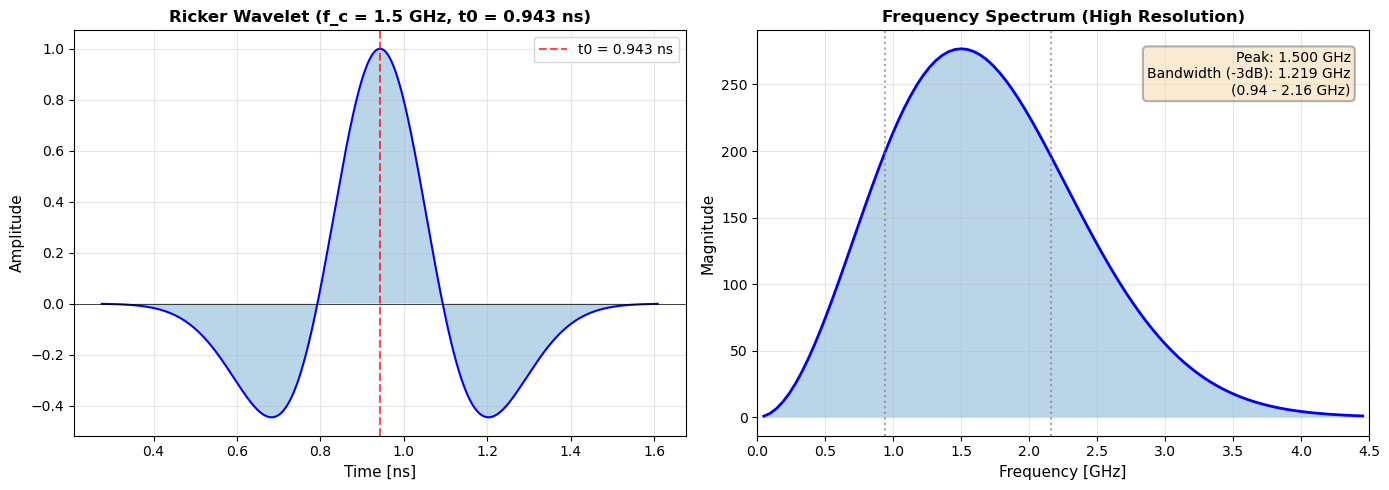

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Ricker wavelet parameters
f_c = 1.5e9  # Central frequency [Hz]
dt = 1e-12   # Time step [s] (1 ps for high frequency content)

# Generate Ricker wavelet with t0_ns time delay
t_max = 2 / f_c  # Duration covering 2 periods
n_samples = int(t_max / dt)
t = np.arange(n_samples) * dt - t_max/2

# Apply time delay
t_delayed = t + t0_ns * 1e-9

ricker = (1 - 2*(np.pi*f_c*t)**2) * np.exp(-(np.pi*f_c*t)**2)

# Compute frequency spectrum with zero-padding for higher resolution
n_fft = n_samples * 16  # 16x zero-padding for smoother spectrum
freqs = np.fft.rfftfreq(n_fft, dt)
spectrum = np.abs(np.fft.rfft(ricker, n=n_fft))

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Time domain
ax1.plot(t_delayed * 1e9, ricker, 'b-', linewidth=1.5)
ax1.fill_between(t_delayed * 1e9, ricker, alpha=0.3)
ax1.set_xlabel('Time [ns]', fontsize=11)
ax1.set_ylabel('Amplitude', fontsize=11)
ax1.set_title(f'Ricker Wavelet (f_c = {f_c/1e9:.1f} GHz, t0 = {t0_ns:.3f} ns)', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.axhline(0, color='k', linewidth=0.5)
ax1.axvline(t0_ns, color='r', linestyle='--', linewidth=1.5, alpha=0.7, label=f't0 = {t0_ns:.3f} ns')
ax1.legend(fontsize=10)

# Frequency domain (linear scale, high resolution)
freq_mask = (freqs > 0.0e9) & (freqs < 4.5e9)
ax2.plot(freqs[freq_mask] / 1e9, spectrum[freq_mask], 'b-', linewidth=2)
ax2.fill_between(freqs[freq_mask] / 1e9, spectrum[freq_mask], alpha=0.3)
ax2.set_xlabel('Frequency [GHz]', fontsize=11)
ax2.set_ylabel('Magnitude', fontsize=11)
ax2.set_title(f'Frequency Spectrum (High Resolution)', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, which='both')
ax2.set_xlim([0.0, 4.5])

# Find peak and -3dB bandwidth
peak_idx = np.argmax(spectrum)
peak_freq = freqs[peak_idx]
spectrum_db = 20 * np.log10(spectrum / spectrum.max() + 1e-10)
peak_db = spectrum_db[peak_idx]
half_power_idx = np.where(spectrum_db >= peak_db - 3)[0]
if len(half_power_idx) > 0:
    f_low = freqs[half_power_idx[0]]
    f_high = freqs[half_power_idx[-1]]
    bandwidth = f_high - f_low
    ax2.axvline(f_low/1e9, color='gray', linestyle=':', linewidth=1.5, alpha=0.7)
    ax2.axvline(f_high/1e9, color='gray', linestyle=':', linewidth=1.5, alpha=0.7)
    ax2.text(0.97, 0.95, 
             f'Peak: {peak_freq/1e9:.3f} GHz\nBandwidth (-3dB): {bandwidth/1e9:.3f} GHz\n({f_low/1e9:.2f} - {f_high/1e9:.2f} GHz)',
             transform=ax2.transAxes, fontsize=10,
             verticalalignment='top', horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6, edgecolor='gray', linewidth=1.5))

plt.tight_layout()
plt.savefig('ricker_wavelet_1p5GHz.png', dpi=150, bbox_inches='tight')
plt.show()

# Generating Geometry Files and Merged B-scans
Only uncomment and run when necessary

In [12]:
# input_lambda_2      = r'resolution_study/study_2lambda/resolution_2lambda.in'
# input_lambda_1      = r'resolution_study/study_1lambda/resolution_1lambda.in'
# input_lambda_0p5    = r'resolution_study/study_0p5lambda/resolution_0p5lambda.in'
# input_lambda_0p25   = r'resolution_study/study_0p25lambda/resolution_0p25lambda.in'
# input_lambda_0p125  = r'resolution_study/study_0p125lambda/resolution_0p125lambda.in'
# input_lambda_0p0625 = r'resolution_study/study_0p0625lambda/resolution_0p0625lambda.in'

# api(input_lambda_2, n=1, geometry_only=True)
# api(input_lambda_1, n=1, geometry_only=True)
# api(input_lambda_0p5, n=1, geometry_only=True)
# api(input_lambda_0p25, n=1, geometry_only=True)
# api(input_lambda_0p125, n=1, geometry_only=True)
# api(input_lambda_0p0625, n=1, geometry_only=True)


In [13]:
# filename_background    = r'resolution_study/background/resolution_background'
# filename_lambda_2      = r'resolution_study/study_2lambda/resolution_2lambda'
# filename_lambda_1      = r'resolution_study/study_1lambda/resolution_1lambda'
# filename_lambda_0p5    = r'resolution_study/study_0p5lambda/resolution_0p5lambda'
# filename_lambda_0p25   = r'resolution_study/study_0p25lambda/resolution_0p25lambda'
# filename_lambda_0p125  = r'resolution_study/study_0p125lambda/resolution_0p125lambda'
# filename_lambda_0p0625 = r'resolution_study/study_0p0625lambda/resolution_0p0625lambda'

# merge_files(filename_background, removefiles=True)
# merge_files(filename_lambda_2, removefiles=True)
# merge_files(filename_lambda_1, removefiles=True)
# merge_files(filename_lambda_0p5, removefiles=True)
# merge_files(filename_lambda_0p25, removefiles=True)
# merge_files(filename_lambda_0p125, removefiles=True)
# merge_files(filename_lambda_0p0625, removefiles=True)


# Loading in the data and removing direct wave

In [14]:
rxnumber    = 1
rxcomponent = 'Ez'

output_background, dt = get_output_data(
    'resolution_study/background/resolution_background_merged.out', rxnumber, rxcomponent
)

_paths = [
    'resolution_study/study_2lambda/resolution_2lambda_merged.out',
    'resolution_study/study_1lambda/resolution_1lambda_merged.out',
    'resolution_study/study_0p5lambda/resolution_0p5lambda_merged.out',
    'resolution_study/study_0p25lambda/resolution_0p25lambda_merged.out',
    'resolution_study/study_0p125lambda/resolution_0p125lambda_merged.out',
    'resolution_study/study_0p0625lambda/resolution_0p0625lambda_merged.out',
]
raw_outputs = [get_output_data(p, rxnumber, rxcomponent)[0] for p in _paths]
outputs     = [r - output_background for r in raw_outputs]   # background-subtracted

dt_ns   = dt * 1e9
n_t     = outputs[0].shape[0]
time_ns = np.arange(n_t) * dt_ns

# Convenience lists for the visualisation cells below
data_pre = [('Background', output_background)] + list(zip(labels, raw_outputs))
data     = list(zip(labels, outputs))

print(f'dt = {dt_ns:.6f} ns,  n_t = {n_t},  t_max = {time_ns[-1]:.2f} ns')
print(f'Data shape (n_t × n_tr): {outputs[0].shape}  ({n_t} time samples × {n_traces} traces)')

dt = 0.002359 ns,  n_t = 8481,  t_max = 20.00 ns
Data shape (n_t × n_tr): (8481, 380)  (8481 time samples × 380 traces)


# Visualisation

C:\Users\Administrator\AppData\Local\Temp\ipykernel_27088\252800132.py:17: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


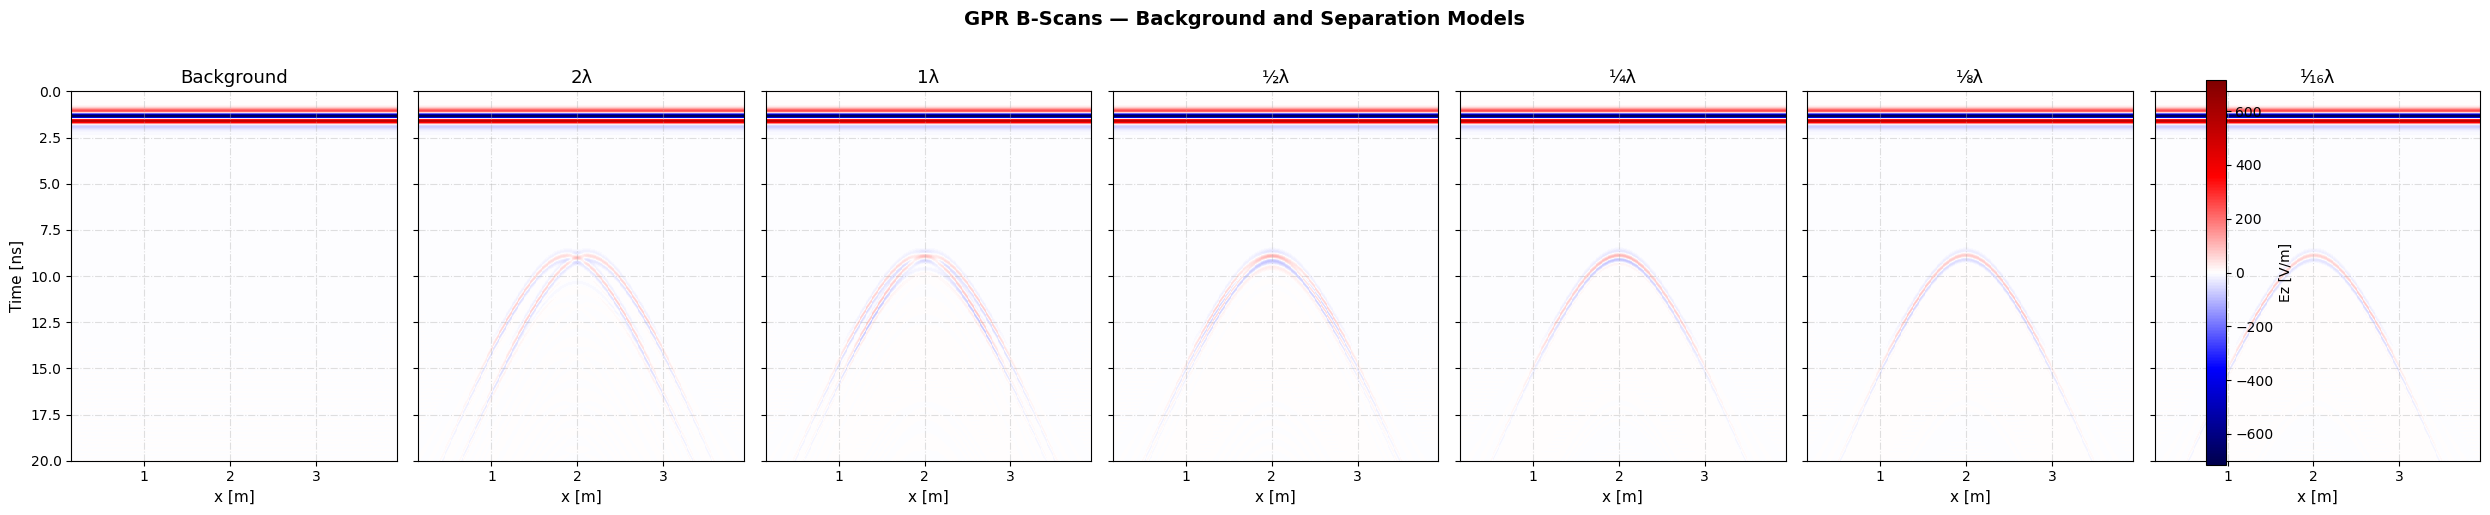

In [15]:
extent_bscan = [x_traces[0], x_traces[-1], time_ns[-1], 0]

fig, axes = plt.subplots(1, 7, figsize=(25, 5), facecolor='w', sharey=True)
vmax = max(np.abs(d).max() for _, d in data_pre)

for ax, (title, d) in zip(axes, data_pre):
    im = ax.imshow(d, aspect='auto', cmap='seismic', extent=extent_bscan,
                   interpolation='nearest', vmin=-vmax, vmax=vmax)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('x [m]', fontsize=11)
    if ax is axes[0]:
        ax.set_ylabel('Time [ns]', fontsize=11)
    ax.grid(linestyle='-.', alpha=0.4)

fig.colorbar(im, ax=axes, fraction=0.02, pad=0.02, label='Ez [V/m]')
fig.suptitle('GPR B-Scans — Background and Separation Models', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_27088\2392914854.py:15: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


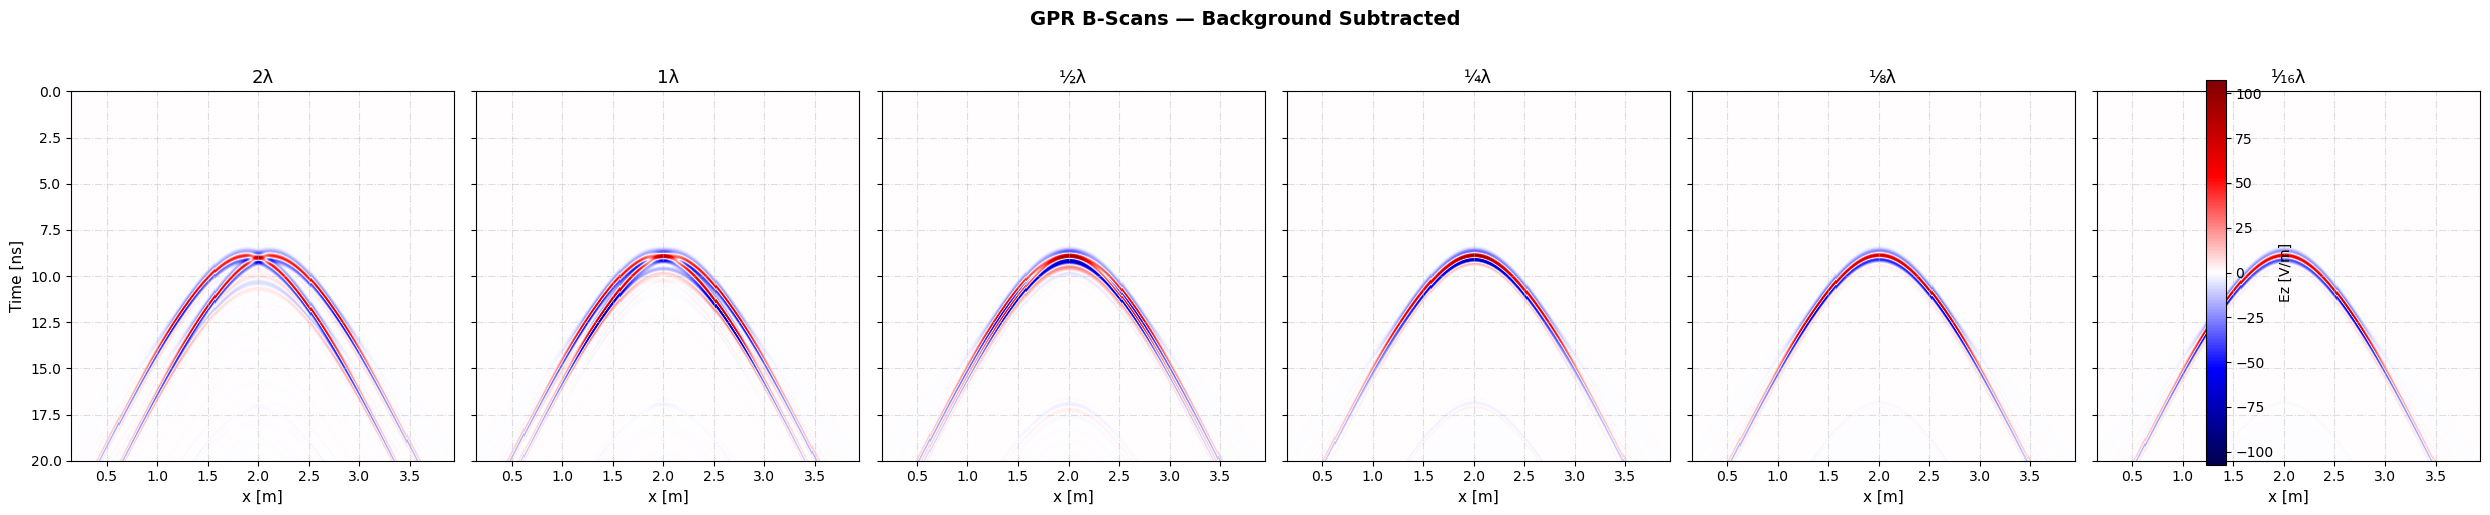

In [16]:
fig, axes = plt.subplots(1, 6, figsize=(25, 5), facecolor='w', sharey=True)
vmax = max(np.abs(d).max() for _, d in data)

for ax, (title, d) in zip(axes, data):
    im = ax.imshow(d, aspect='auto', cmap='seismic', extent=extent_bscan,
                   interpolation='nearest', vmin=-vmax, vmax=vmax)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('x [m]', fontsize=11)
    if ax is axes[0]:
        ax.set_ylabel('Time [ns]', fontsize=11)
    ax.grid(linestyle='-.', alpha=0.4)

fig.colorbar(im, ax=axes, fraction=0.02, pad=0.02, label='Ez [V/m]')
fig.suptitle('GPR B-Scans — Background Subtracted', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Kirchhoff Migration

Delay-and-sum migration via the **PyLops zero-offset Kirchhoff operator**.  
Each dataset is preprocessed (tapering + t0 shift — see cell above) before being migrated.  
Green stars mark the true cylinder-top positions.

In [17]:
def PylopsKirchoffMigration(data, t, x, vel_model, z,wav='Ricker', wavcenter='Center',f0=0.08 ,recs = None, srcs = None, mode='analytic', dynamic=False,
aperture=None, angleaperture=None, return_op=False):
    """
    Perform Kirchhoff migration using PyLops zero offset operator. pass ns, gHz and meter 
    """
    import numpy as np
    import KirchhoffPylopsZeroOffset
    import importlib
    importlib.reload(KirchhoffPylopsZeroOffset)
    from pylops.utils.wavelets import ricker
    
    # For zero-offset, srcs = recs
    rx = x
    rz = np.zeros_like(rx)
    recs = np.vstack((rx, rz))
    srcs = recs

    # Handle wavelet selection
    if wav == 'Ricker':
        # Generate a short wavelet: 6 cycles, centered at zero, dependent on f0
        n_cycles = 6
        period_ns = 1.0 / f0 # t in ns, f0 in GHz
        wav_duration = n_cycles * period_ns # total duration in ns
        n_wav_samples = int(np.ceil(wav_duration / (t[1] - t[0])))
        # Ensure odd number for center
        if n_wav_samples % 2 == 0:
            n_wav_samples += 1
        wav_arr, trick, wcenter = ricker(t[0:n_wav_samples], f0=f0)
    else:
        wav_arr = wav
        
    if wavcenter == 'Center':
        wavcenter = wcenter

    # Build Zero Offset Kirchhoff operator
    K = KirchhoffPylopsZeroOffset.Kirchhoff(
        z=z, x=x, t=t,
        srcs=srcs, recs=recs,
        vel=vel_model,
        wav=wav_arr, wavcenter=wavcenter,
        mode=mode, dynamic=dynamic,
        aperture=aperture, angleaperture=angleaperture
    )

    d = data.flatten()
    print("d.shape:", d.shape, "K dimension:", K.shape)

    # Migrate: apply adjoint
    m = K.H @ d
    
    # Reshape to (nz, nx)
    m = m.reshape(len(x), len(z)).T
    
    if return_op:
        return m, K
    return m

## Tapering & t0 Shift

Two pre-processing steps applied to every B-scan before migration:

| Step | Purpose |
|------|---------|
| **Exponential decay taper** (`taper_decay_ns`) | Suppresses late arrivals, emphasises hyperbola apices |
| **Cosine end taper** (`taper_end_ns`) | Zeros the final portion of each trace to remove hyperbola tails |
| **t0 shift** | Removes the Ricker wavelet's built-in peak delay so that t = 0 aligns with the surface |

Adjust the parameters in the cell below and re-run to see their effect on the B-scan.

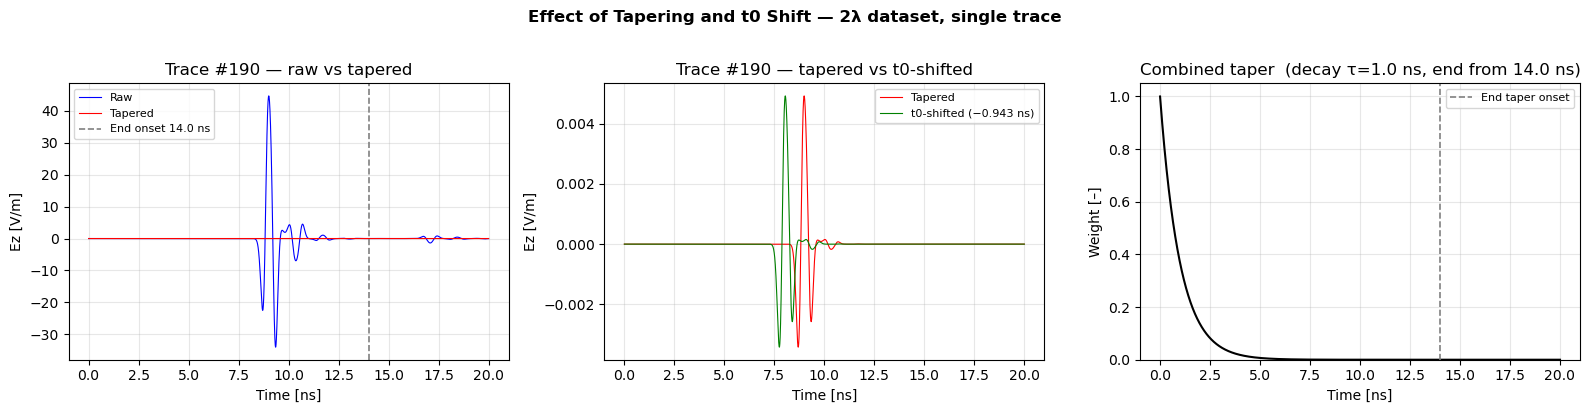

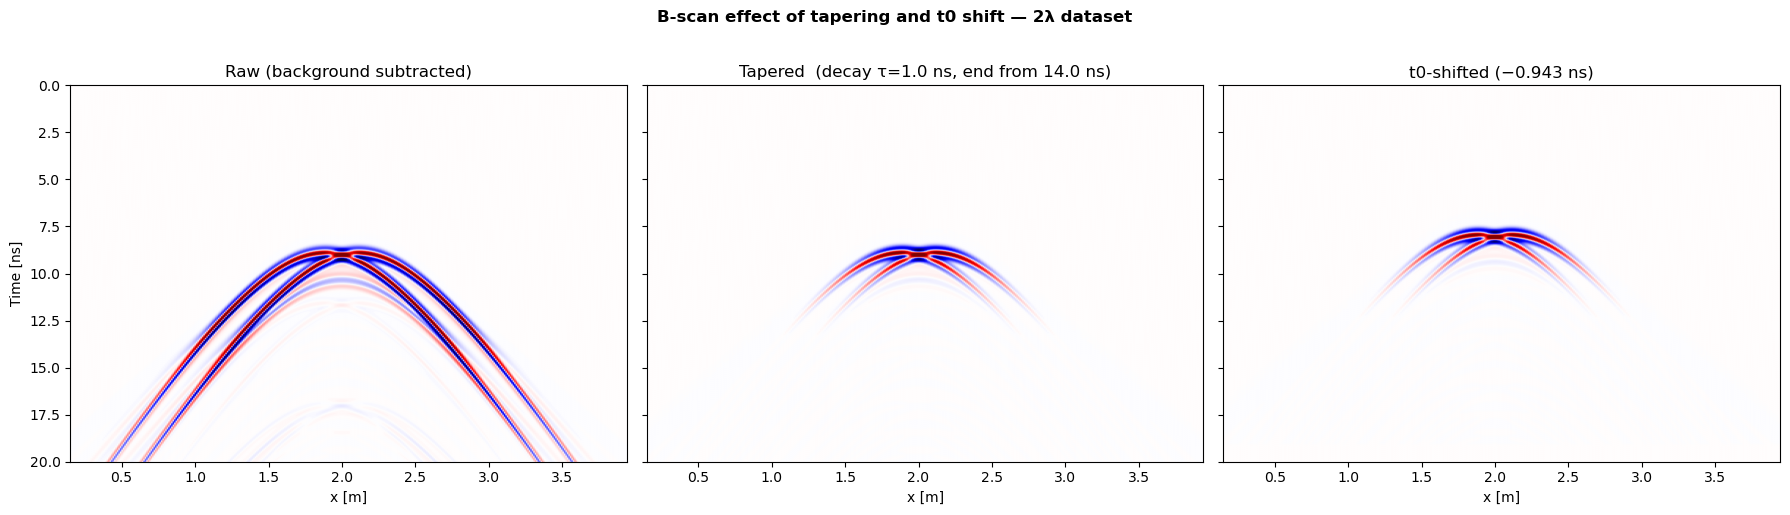

In [18]:
# ── Taper & t0-shift parameters ───────────────────────────────────────────────
taper_end_ns   = 14.0   # cosine ramp onset [ns]: zeros hyperbola tails beyond this time
taper_decay_ns = 1.0    # exponential decay time constant [ns]: de-emphasises late arrivals
ANGLE_AP       = 40     # Kirchhoff aperture half-angle [degrees]

# ── Functions ─────────────────────────────────────────────────────────────────
def make_end_taper(n_samples, taper_samples):
    """Unity everywhere, then half-cosine 1→0 over the last `taper_samples`."""
    win = np.ones(n_samples)
    if taper_samples > 0:
        ramp = 0.5 * (1 + np.cos(np.pi * np.arange(taper_samples) / taper_samples))
        win[-taper_samples:] = ramp
    return win

def make_decay_taper(time_ns, tau_ns):
    """Exponential decay starting at 1.0 (t=0) with time constant tau_ns."""
    return np.exp(-time_ns / tau_ns)

def preprocess(data_nt_ntr, dt_ns, t0_ns, time_ns):
    """
    Prepare a B-scan for Kirchhoff migration.
    Input:  data_nt_ntr  (n_t, n_tr)  — background-subtracted B-scan
    Returns tapered (n_tr, n_t) and t0-shifted (n_tr, n_t) arrays.
    """
    bscan   = data_nt_ntr.T.copy()                              # → (n_tr, n_t)
    n_t     = bscan.shape[1]
    w_end   = make_end_taper(n_t, int(round(taper_end_ns / dt_ns)))
    w_decay = make_decay_taper(time_ns, taper_decay_ns)
    tapered = bscan * (w_end * w_decay)[np.newaxis, :]
    t0_samp = int(round(t0_ns / dt_ns))
    shifted = np.roll(tapered, -t0_samp, axis=1)
    shifted[:, -t0_samp:] = 0.0
    return tapered, shifted

# ── Visualise effect on the 2λ dataset ────────────────────────────────────────
_demo = outputs[0]    # (n_t, n_tr)
_raw_tr, _shifted = preprocess(_demo, dt_ns, t0_ns, time_ns)
_tapered = _raw_tr   # preprocess returns tapered as first output

w_end_vis   = make_end_taper(n_t, int(round(taper_end_ns   / dt_ns)))
w_decay_vis = make_decay_taper(time_ns, taper_decay_ns)
taper_combined = w_end_vis * w_decay_vis

mid_tr = n_traces // 2   # representative central trace

# --- Row 1: single-trace before/after ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(time_ns, _demo[:, mid_tr], 'b', lw=0.8, label='Raw')
axes[0].plot(time_ns, _tapered[mid_tr], 'r', lw=0.8, label='Tapered')
axes[0].axvline(taper_end_ns, color='gray', ls='--', lw=1.2, label=f'End onset {taper_end_ns} ns')
axes[0].set(xlabel='Time [ns]', ylabel='Ez [V/m]', title=f'Trace #{mid_tr} — raw vs tapered')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

axes[1].plot(time_ns, _tapered[mid_tr], 'r', lw=0.8, label='Tapered')
axes[1].plot(time_ns, _shifted[mid_tr], 'g', lw=0.8, label=f't0-shifted (−{t0_ns:.3f} ns)')
axes[1].set(xlabel='Time [ns]', ylabel='Ez [V/m]', title=f'Trace #{mid_tr} — tapered vs t0-shifted')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

axes[2].plot(time_ns, taper_combined, 'k', lw=1.5)
axes[2].axvline(taper_end_ns, color='gray', ls='--', lw=1.2, label=f'End taper onset')
axes[2].set(xlabel='Time [ns]', ylabel='Weight [–]',
            title=f'Combined taper  (decay τ={taper_decay_ns} ns, end from {taper_end_ns} ns)',
            ylim=(0, 1.05))
axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3)

plt.suptitle('Effect of Tapering and t0 Shift — 2λ dataset, single trace', fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

# --- Row 2: full B-scan comparison ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
kw = dict(aspect='auto', cmap='seismic', extent=extent_bscan, origin='upper')

vmax0 = np.max(np.abs(_demo)) * 0.5
axes[0].imshow(_demo, **kw, vmin=-vmax0, vmax=vmax0)
axes[0].set(title='Raw (background subtracted)', xlabel='x [m]', ylabel='Time [ns]')

vmax1 = np.max(np.abs(_tapered)) * 0.5
axes[1].imshow(_tapered.T, **kw, vmin=-vmax1, vmax=vmax1)
axes[1].set(title=f'Tapered  (decay τ={taper_decay_ns} ns, end from {taper_end_ns} ns)', xlabel='x [m]')

vmax2 = np.max(np.abs(_shifted)) * 0.5
axes[2].imshow(_shifted.T, **kw, vmin=-vmax2, vmax=vmax2)
axes[2].set(title=f't0-shifted (−{t0_ns:.3f} ns)', xlabel='x [m]')

plt.suptitle('B-scan effect of tapering and t0 shift — 2λ dataset', fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

## Run Migration on All Datasets

In [19]:
# ── Kirchhoff migration on all 6 datasets ─────────────────────────────────────
migrated = {}

for label, raw in zip(labels, outputs):
    _, shifted = preprocess(raw, dt_ns, t0_ns, time_ns)   # (n_tr, n_t), t0-shifted
    print(f'[{label}] Running Kirchhoff ...', end=' ', flush=True)
    t0 = _time.perf_counter()
    img = PylopsKirchoffMigration(
        shifted, time_ns, x_traces, v_ice, z_img,
        f0=f_c_GHz, angleaperture=ANGLE_AP
    )
    print(f'{_time.perf_counter()-t0:.1f} s  shape={img.shape}')
    migrated[label] = img

[2λ] Running Kirchhoff ... d.shape: (3222780,) K dimension: (3222780, 60800)
10.4 s  shape=(160, 380)
[1λ] Running Kirchhoff ... d.shape: (3222780,) K dimension: (3222780, 60800)
2.4 s  shape=(160, 380)
[½λ] Running Kirchhoff ... d.shape: (3222780,) K dimension: (3222780, 60800)
2.3 s  shape=(160, 380)
[¼λ] Running Kirchhoff ... d.shape: (3222780,) K dimension: (3222780, 60800)
2.3 s  shape=(160, 380)
[⅛λ] Running Kirchhoff ... d.shape: (3222780,) K dimension: (3222780, 60800)
2.3 s  shape=(160, 380)
[¹⁄₁₆λ] Running Kirchhoff ... d.shape: (3222780,) K dimension: (3222780, 60800)
2.3 s  shape=(160, 380)


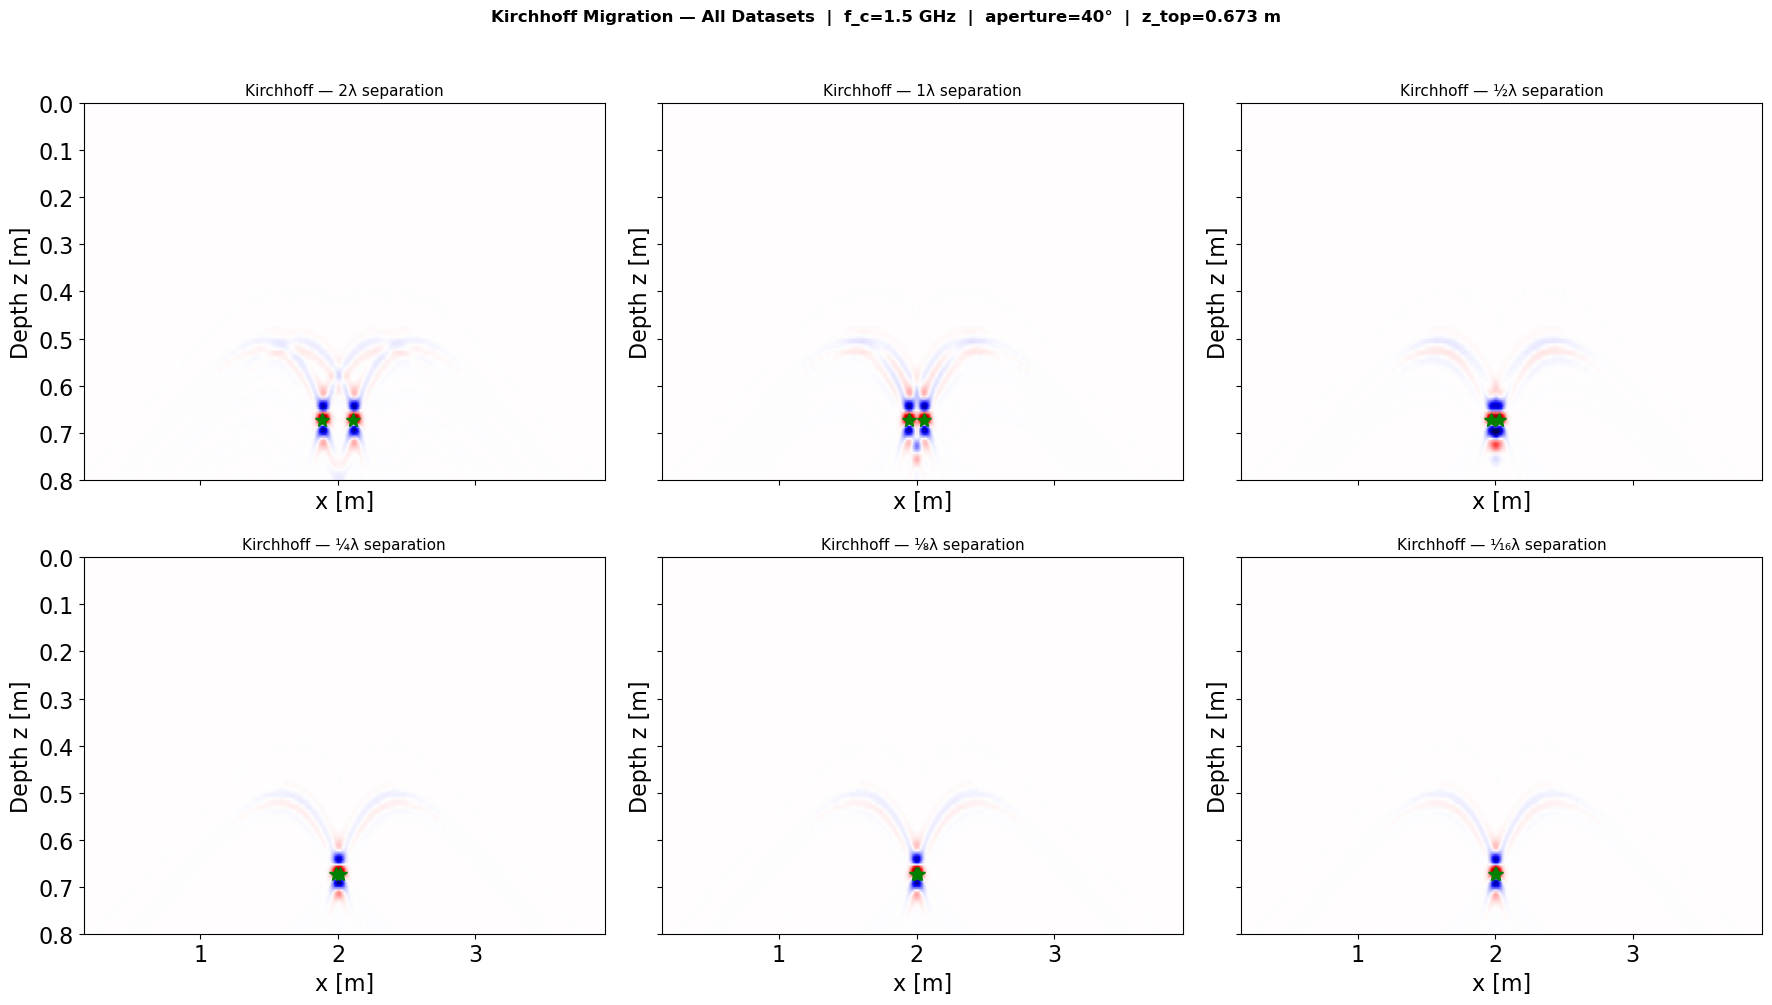

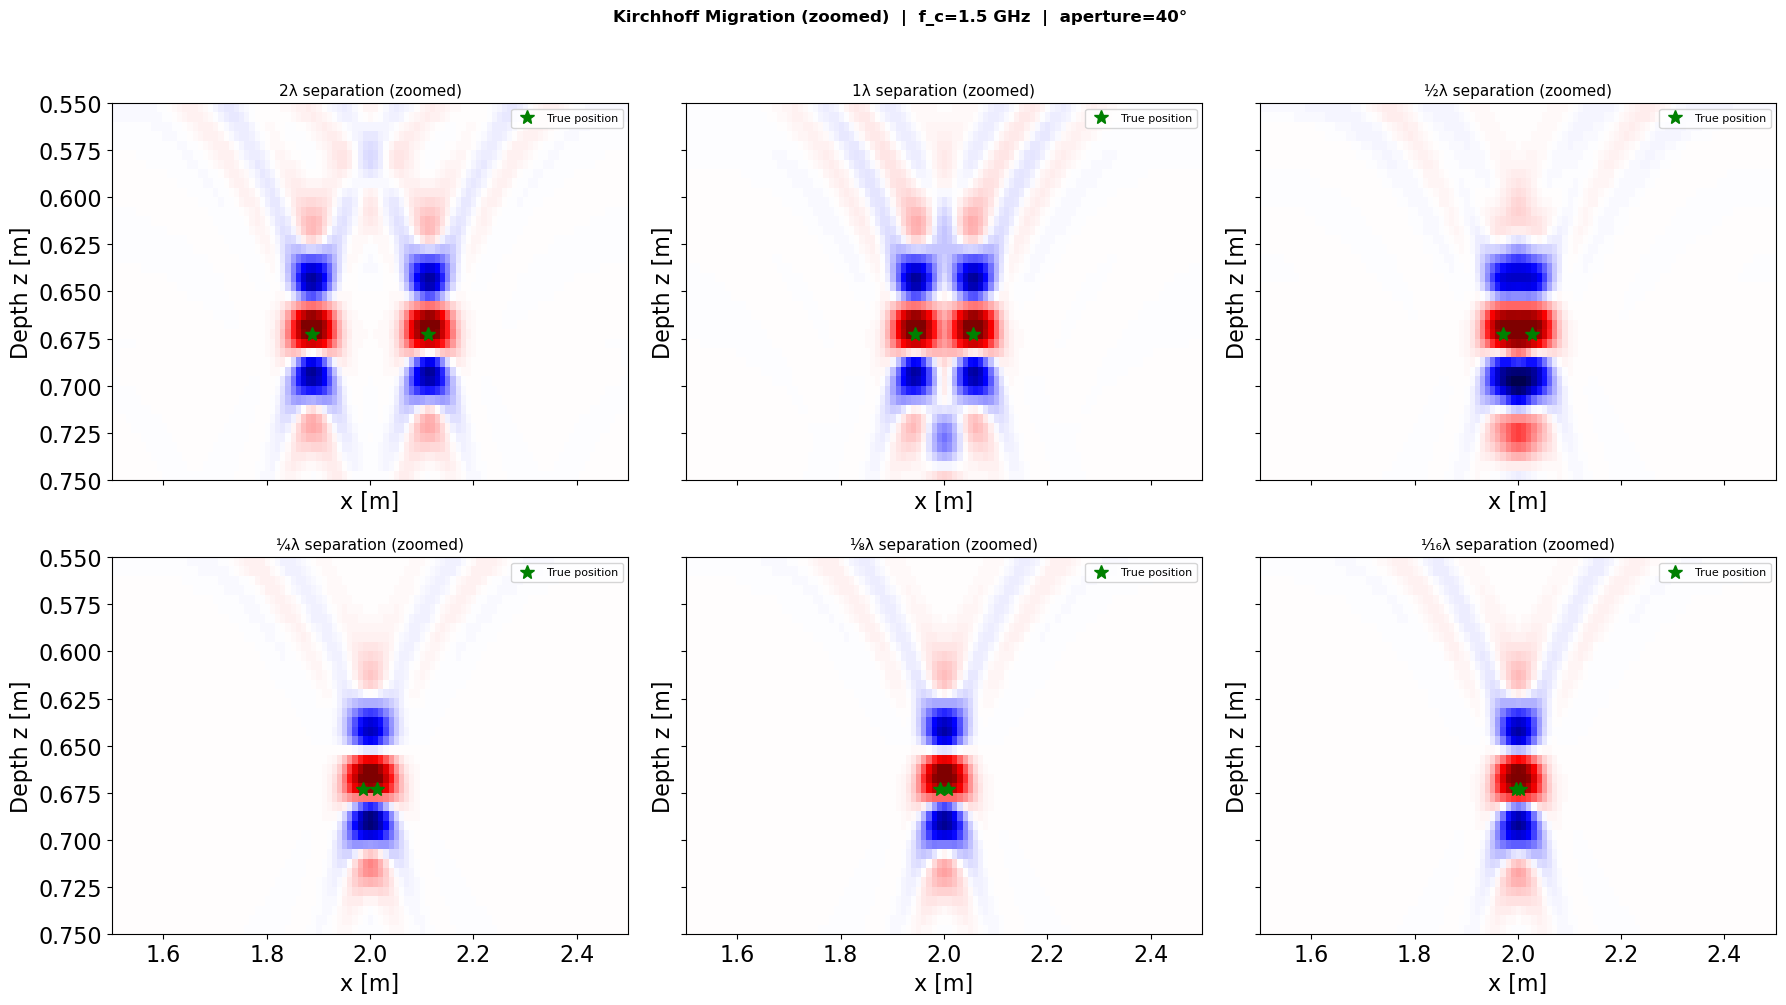

In [20]:
# ── Plot: full extent ──────────────────────────────────────────────────────────
extent_mig = [x_traces[0], x_traces[-1], z_img[-1], z_img[0]]

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)
for ax, (label, img), x1, x2 in zip(axes.ravel(), migrated.items(), x_s1_all, x_s2_all):
    vmax = np.max(np.abs(img)) * 0.8
    ax.imshow(img, aspect='auto', cmap='seismic', vmin=-vmax, vmax=vmax,
              extent=extent_mig, origin='upper')
    ax.plot([x1, x2], [z_top, z_top], 'g*', ms=10, zorder=5)
    ax.set_title(f'Kirchhoff — {label} separation', fontsize=11)
    ax.set_xlabel('x [m]'); ax.set_ylabel('Depth z [m]')

plt.suptitle(
    f'Kirchhoff Migration — All Datasets  |  f_c={f_c_GHz} GHz  |  aperture={ANGLE_AP}°  |  z_top={z_top:.3f} m',
    fontsize=12, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig(STUDY_ROOT / 'kirchhoff_all_datasets.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot: zoomed on scatterer region ──────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)
for ax, (label, img), x1, x2 in zip(axes.ravel(), migrated.items(), x_s1_all, x_s2_all):
    vmax = np.max(np.abs(img)) * 0.8
    ax.imshow(img, aspect='auto', cmap='seismic', vmin=-vmax, vmax=vmax,
              extent=extent_mig, origin='upper')
    ax.plot([x1, x2], [z_top, z_top], 'g*', ms=10, zorder=5, label='True position')
    ax.set_xlim(1.5, 2.5); ax.set_ylim(0.75, 0.55)
    ax.set_title(f'{label} separation (zoomed)', fontsize=11)
    ax.set_xlabel('x [m]'); ax.set_ylabel('Depth z [m]')
    ax.legend(fontsize=8, loc='upper right')

plt.suptitle(
    f'Kirchhoff Migration (zoomed)  |  f_c={f_c_GHz} GHz  |  aperture={ANGLE_AP}°',
    fontsize=12, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig(STUDY_ROOT / 'kirchhoff_all_datasets_zoomed.png', dpi=150, bbox_inches='tight')
plt.show()

# Gazdag Phase-Shift Migration

f-k domain migration via **PyLops `PhaseShift`** downward continuation.  
Uses the same preprocessed (tapered + t0-shifted) B-scans as Kirchhoff, but operates in the
frequency-wavenumber domain: each depth step phase-shifts the wavefield by `kz·dz`.

Key implementation details:
- `v_mig = v_ice / 2` (exploding-reflector half-velocity) used internally
- 100 % spatial zero-padding each side to avoid wrap-around in kx
- Evanescent bins (`|kx| > |f|/v_mig`) are zeroed **before** the depth loop to prevent smile artefacts accumulating at the t = 0 imaging condition
- Green stars mark the true cylinder-top positions

_____________
Add padding in space and time up to the next power of 2
_____________

In [21]:
import pylops

def gazdag_migration(data, x, t, z, vel):
    """
    Gazdag (1978) phase-shift migration for zero-offset post-stack data.

    data : (n_t, n_x)  B-scan, time axis first, t0-shifted
    x, t : 1-D arrays [m, ns]
    z    : 1-D depth axis [m], uniformly spaced from 0
    vel  : full medium velocity [m/ns]; v_mig = vel/2 used internally

    Returns image (n_z, n_x), peak-normalised to ±1.
    """
    n_t, n_x = data.shape
    dt    = float(t[1] - t[0])
    dx    = float(x[1] - x[0])
    dz    = float(z[1] - z[0])
    v_mig = vel / 2.0

    # Spatial cosine taper (5%) + 100% zero-pad each side → nx_pad = 3*n_x
    n_xtap  = max(3, int(0.05 * n_x))
    pad     = n_x
    sp_tap  = pylops.utils.tapers.taper2d(n_t, n_x, n_xtap)   # (n_x, n_t)
    data_sp = np.pad(
        data.T * sp_tap,   # (n_x, n_t)
        ((pad, pad), (0, 0)),
        mode='constant'
    )                      # (nx_pad, n_t)
    nx_pad = n_x + 2 * pad

    # f-kx dip filter: zero evanescent bins before migration to prevent smile artefacts
    D_fk       = np.fft.fft(np.fft.rfft(data_sp, axis=1), axis=0)   # (nx_pad, n_f)
    freq_arr   = np.fft.rfftfreq(n_t, dt)          # [GHz]
    kx_arr     = np.fft.fftfreq(nx_pad, dx)        # [1/m]
    evanescent = np.abs(kx_arr[:, None]) > np.abs(freq_arr[None, :]) / v_mig
    D_fk[evanescent] = 0.0
    data_sp = np.real(np.fft.irfft(np.fft.ifft(D_fk, axis=0), n=n_t, axis=1))

    print(f'  nx={n_x} → nx_pad={nx_pad},  evanescent bins zeroed: '
          f'{evanescent.sum()}/{evanescent.size} ({100*evanescent.mean():.1f}%)')

    # PhaseShift depth loop: downward continuation + t=0 imaging condition
    freq  = np.fft.rfftfreq(n_t, dt)
    kx    = np.fft.fftshift(np.fft.fftfreq(nx_pad, dx))
    Pop   = pylops.waveeqprocessing.PhaseShift(v_mig, dz, n_t, freq, kx)
    field = data_sp.T.ravel()   # (n_t * nx_pad,) row-major

    image = np.zeros((len(z), n_x))
    for iz in range(len(z)):
        image[iz] = np.real(field.reshape(n_t, nx_pad)[0, pad:-pad])
        if iz < len(z) - 1:
            field = Pop.H * field   # adjoint PhaseShift = downward continuation

    peak = np.max(np.abs(image))
    return image / (peak + 1e-30)

## Run Migration on All Datasets

In [22]:
# ── Gazdag phase-shift migration on all 6 datasets ────────────────────────────
migrated_gz = {}

for label, raw in zip(labels, outputs):
    _, shifted = preprocess(raw, dt_ns, t0_ns, time_ns)   # (n_tr, n_t), t0-shifted
    print(f'[{label}] Running Gazdag ...', flush=True)
    t0 = _time.perf_counter()
    img = gazdag_migration(
        shifted.T,       # (n_t, n_tr) — time first
        x_traces, time_ns, z_img, v_ice
    )
    print(f'  Done in {_time.perf_counter()-t0:.1f} s  shape={img.shape}')
    migrated_gz[label] = img

[2λ] Running Gazdag ...
  nx=380 → nx_pad=1140,  evanescent bins zeroed: 48725/4834740 (1.0%)
  Done in 140.6 s  shape=(160, 380)
[1λ] Running Gazdag ...
  nx=380 → nx_pad=1140,  evanescent bins zeroed: 48725/4834740 (1.0%)
  Done in 145.5 s  shape=(160, 380)
[½λ] Running Gazdag ...
  nx=380 → nx_pad=1140,  evanescent bins zeroed: 48725/4834740 (1.0%)
  Done in 144.1 s  shape=(160, 380)
[¼λ] Running Gazdag ...
  nx=380 → nx_pad=1140,  evanescent bins zeroed: 48725/4834740 (1.0%)
  Done in 138.6 s  shape=(160, 380)
[⅛λ] Running Gazdag ...
  nx=380 → nx_pad=1140,  evanescent bins zeroed: 48725/4834740 (1.0%)
  Done in 137.5 s  shape=(160, 380)
[¹⁄₁₆λ] Running Gazdag ...
  nx=380 → nx_pad=1140,  evanescent bins zeroed: 48725/4834740 (1.0%)
  Done in 141.2 s  shape=(160, 380)


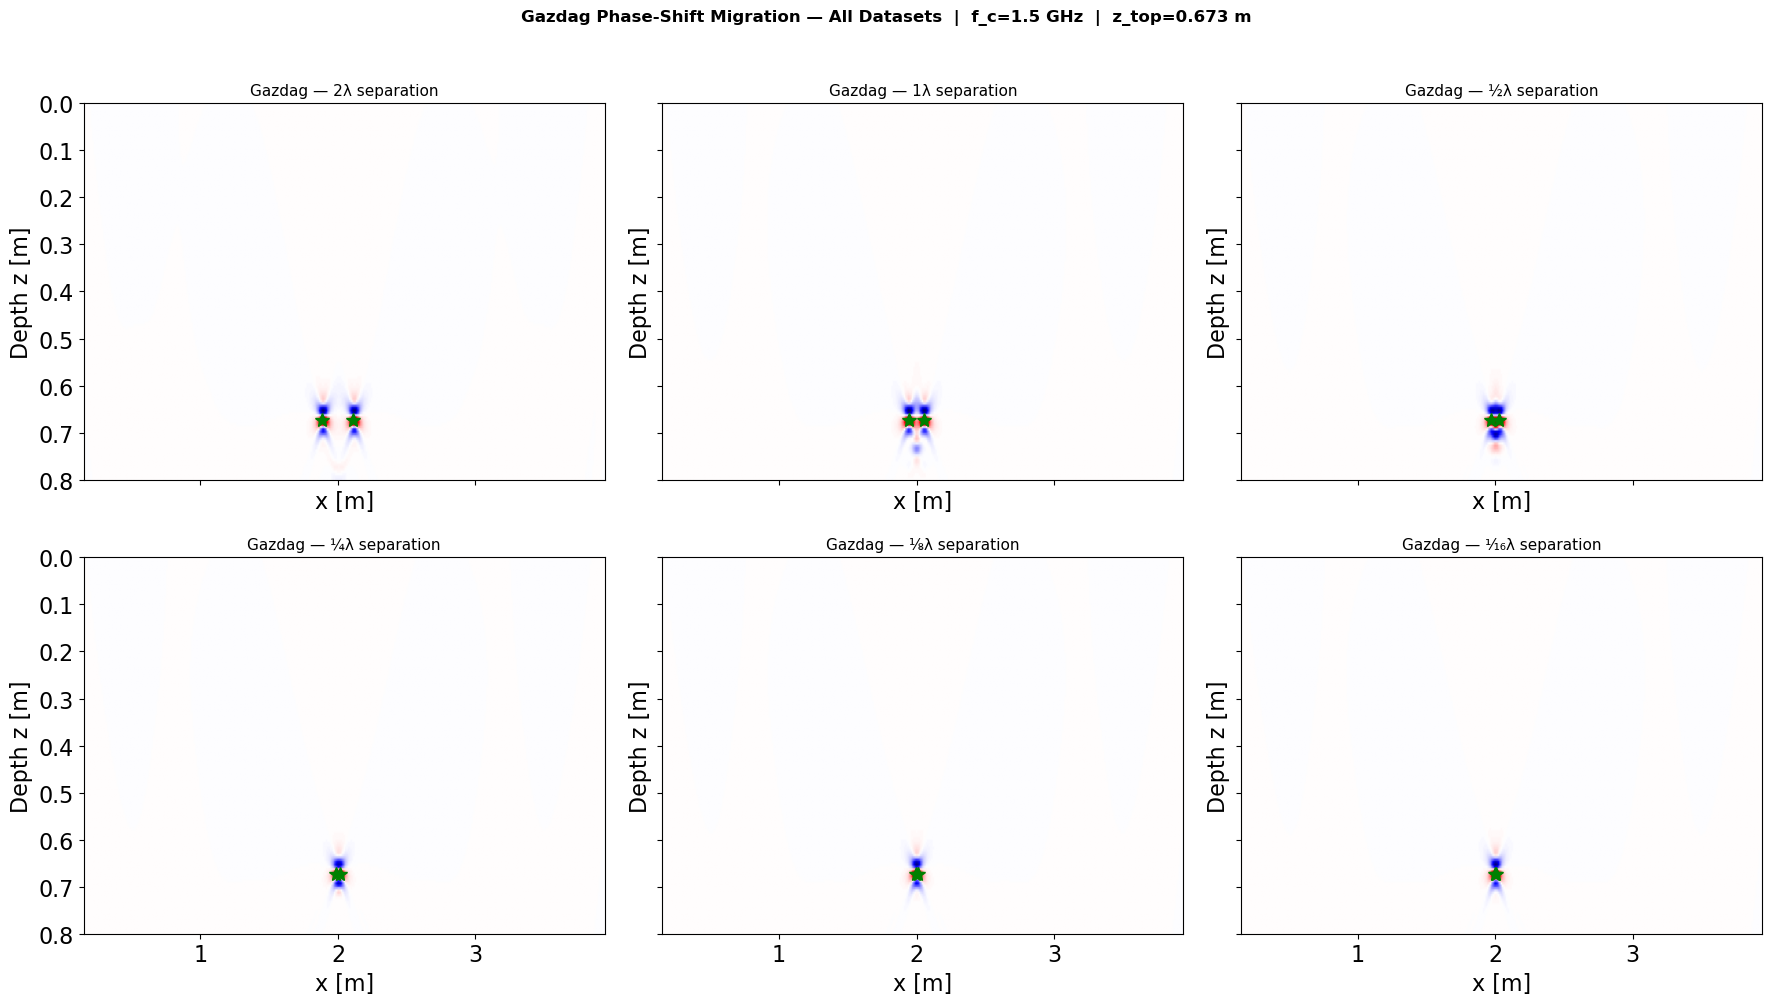

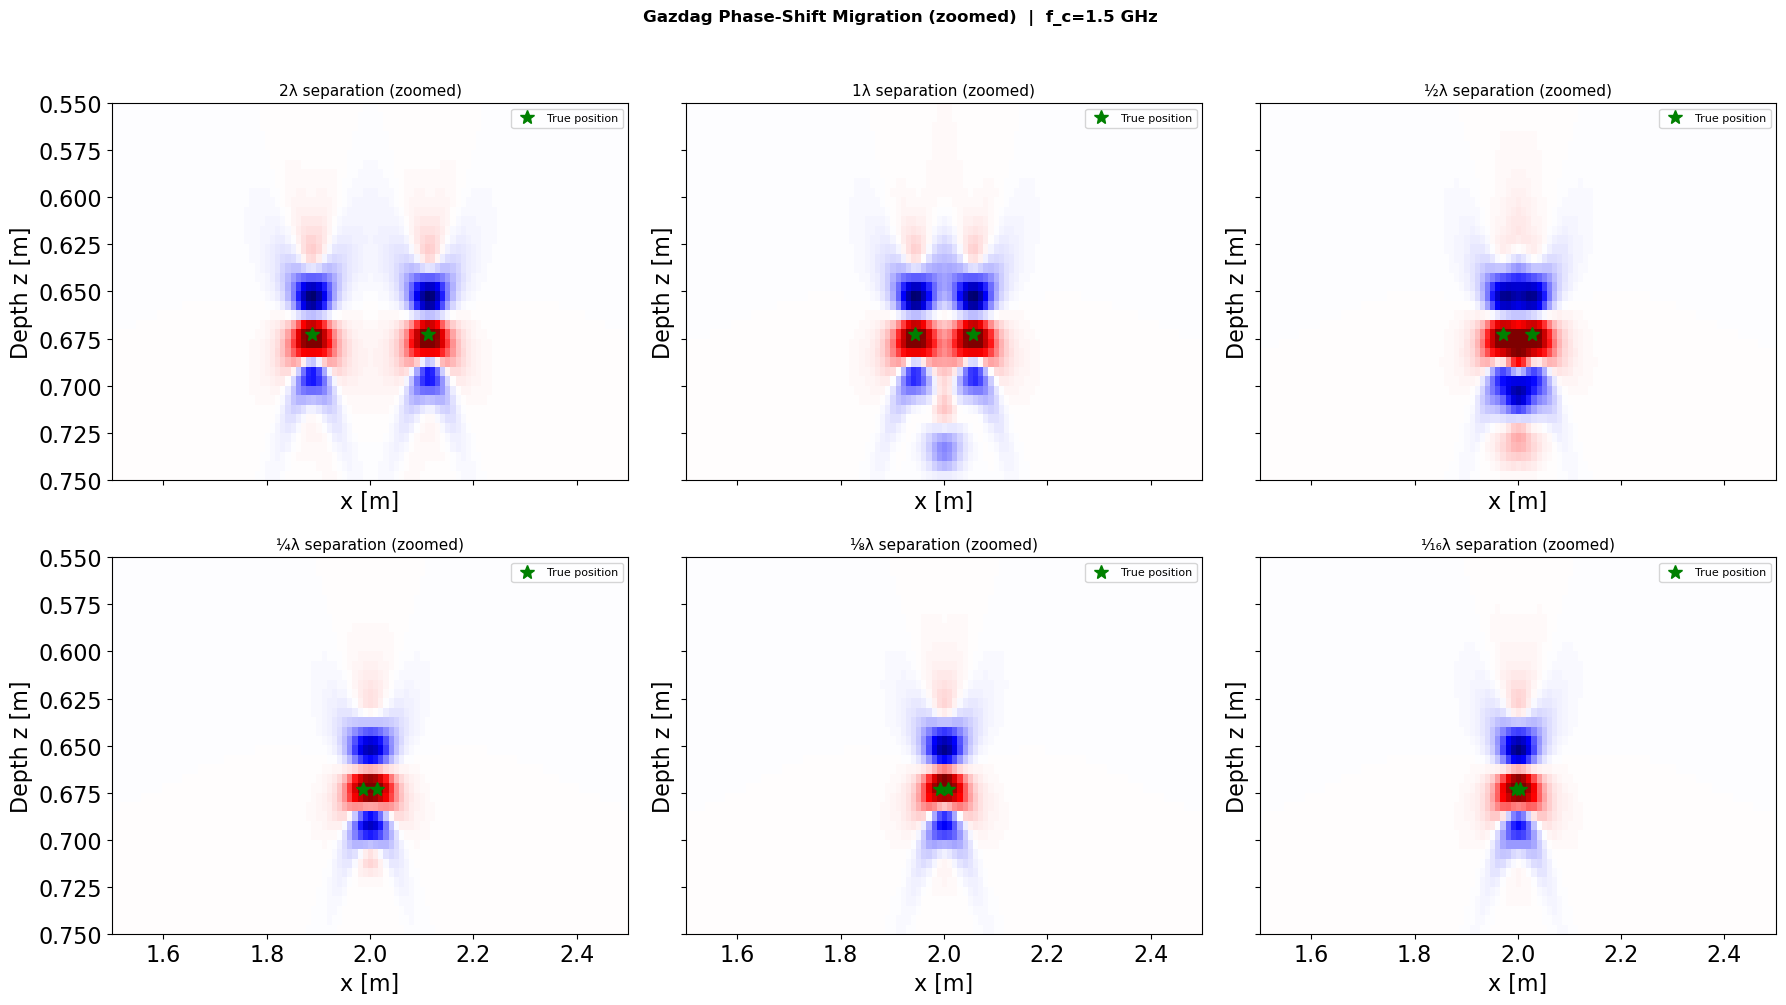

In [23]:
# ── Plot: full extent ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)
for ax, (label, img), x1, x2 in zip(axes.ravel(), migrated_gz.items(), x_s1_all, x_s2_all):
    vmax = np.max(np.abs(img)) * 0.8
    ax.imshow(img, aspect='auto', cmap='seismic', vmin=-vmax, vmax=vmax,
              extent=extent_mig, origin='upper')
    ax.plot([x1, x2], [z_top, z_top], 'g*', ms=10, zorder=5)
    ax.set_title(f'Gazdag — {label} separation', fontsize=11)
    ax.set_xlabel('x [m]'); ax.set_ylabel('Depth z [m]')

plt.suptitle(
    f'Gazdag Phase-Shift Migration — All Datasets  |  f_c={f_c_GHz} GHz  |  z_top={z_top:.3f} m',
    fontsize=12, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig(STUDY_ROOT / 'gazdag_all_datasets.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot: zoomed on scatterer region ──────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)
for ax, (label, img), x1, x2 in zip(axes.ravel(), migrated_gz.items(), x_s1_all, x_s2_all):
    vmax = np.max(np.abs(img)) * 0.8
    ax.imshow(img, aspect='auto', cmap='seismic', vmin=-vmax, vmax=vmax,
              extent=extent_mig, origin='upper')
    ax.plot([x1, x2], [z_top, z_top], 'g*', ms=10, zorder=5, label='True position')
    ax.set_xlim(1.5, 2.5); ax.set_ylim(0.75, 0.55)
    ax.set_title(f'{label} separation (zoomed)', fontsize=11)
    ax.set_xlabel('x [m]'); ax.set_ylabel('Depth z [m]')
    ax.legend(fontsize=8, loc='upper right')

plt.suptitle(
    f'Gazdag Phase-Shift Migration (zoomed)  |  f_c={f_c_GHz} GHz',
    fontsize=12, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig(STUDY_ROOT / 'gazdag_all_datasets_zoomed.png', dpi=150, bbox_inches='tight')
plt.show()

# Least-Squares Migration (LSM): Data Domain

Iterative inversion of the Kirchhoff operator **K**: find model **m** such that `Km ≈ d`.  
Applied only to the **2λ dataset** — each inversion is expensive due to the large operator size.

| Solver | Objective | Tuning parameter |
|--------|-----------|-----------------|
| Adjoint | `K^H d` (Kirchhoff migration, baseline) | — |
| LSQR (Tikhonov) | `min ‖Km−d‖² + λ²‖m‖²` | `damp` (λ) |
| FISTA (L1 sparse) | `min ‖Km−d‖² + ε‖m‖₁` | `eps_frac` (ε as % of adjoint peak) |

**Workflow:**  
1. Build the operator K and compute the adjoint image  
2. Sweep regularisation parameters via **L-curve** + **focusing score**  
3. Run the final solvers with the optimal parameters

In [24]:
from scipy.sparse.linalg import lsqr as sp_lsqr

# ── Preprocessed 2λ data ──────────────────────────────────────────────────────
_, shifted_2lam = preprocess(outputs[0], dt_ns, t0_ns, time_ns)   # (n_tr, n_t)

# ── Build Kirchhoff operator (once, reused for all solvers) ───────────────────
print('Building Kirchhoff operator for 2λ dataset ...')
t_op = _time.perf_counter()
m_adj, lsm_K = PylopsKirchoffMigration(
    shifted_2lam, time_ns, x_traces, v_ice, z_img,
    f0=f_c_GHz, angleaperture=ANGLE_AP, return_op=True
)
d_lsm        = shifted_2lam.flatten()
n_x_lsm      = len(x_traces)
n_z_lsm      = len(z_img)
adjoint_peak = np.max(np.abs(m_adj))

print(f'  K: {lsm_K.shape}  built in {_time.perf_counter()-t_op:.1f} s')
print(f'  d: {d_lsm.shape},  adjoint peak = {adjoint_peak:.3e}')

# ── Lipschitz constant via power iteration (needed for FISTA step size) ───────
print('\nEstimating Lipschitz constant (20 power iterations) ...')
np.random.seed(42)
_x_pr = np.random.randn(n_x_lsm * n_z_lsm)
_x_pr /= np.linalg.norm(_x_pr)
for _ in range(20):
    _x_pr = lsm_K.H @ (lsm_K @ _x_pr)
    _lip  = np.linalg.norm(_x_pr)
    _x_pr /= (_lip + 1e-30)
alpha_fista = 1.0 / _lip
print(f'  ‖K‖² ≈ {_lip:.3e},  step α = {alpha_fista:.3e}')

Building Kirchhoff operator for 2λ dataset ...
d.shape: (3222780,) K dimension: (3222780, 60800)
  K: (3222780, 60800)  built in 2.3 s
  d: (3222780,),  adjoint peak = 2.998e+01

Estimating Lipschitz constant (20 power iterations) ...
  ‖K‖² ≈ 3.442e+05,  step α = 2.905e-06


In [25]:
# ── Focusing-score and L-curve helpers ────────────────────────────────────────
x1_true, x2_true = x_s1_all[0], x_s2_all[0]
ix1 = np.argmin(np.abs(x_traces - x1_true))
ix2 = np.argmin(np.abs(x_traces - x2_true))
iz  = np.argmin(np.abs(z_img    - z_top))
HW_X, HW_Z = 6, 4

print(f'Scatterer pixel positions:')
print(f'  s1: x={x_traces[ix1]:.4f} m (true {x1_true:.4f} m)  ix={ix1}')
print(f'  s2: x={x_traces[ix2]:.4f} m (true {x2_true:.4f} m)  ix={ix2}')
print(f'   z: z={z_img[iz]:.4f} m     (true {z_top:.4f} m)    iz={iz}')

def focusing_score(img):
    """Signal / background-RMS ratio using known scatterer positions."""
    def _win(ix_c):
        return img[max(0,iz-HW_Z):iz+HW_Z+1, max(0,ix_c-HW_X):ix_c+HW_X+1]
    signal = 0.5 * (np.max(np.abs(_win(ix1))) + np.max(np.abs(_win(ix2))))
    mask   = np.ones(img.shape, dtype=bool)
    for ix_c in (ix1, ix2):
        mask[max(0,iz-HW_Z):iz+HW_Z+1, max(0,ix_c-HW_X):ix_c+HW_X+1] = False
    return signal / (np.sqrt(np.mean(img[mask]**2)) + 1e-30)

def lcurve_corner(res_arr, norm_arr):
    """Index of maximum curvature in log-log space."""
    eta = np.log(np.maximum(norm_arr, 1e-30))
    rho = np.log(np.maximum(res_arr,  1e-30))
    de, dr   = np.gradient(eta), np.gradient(rho)
    d2e, d2r = np.gradient(de),  np.gradient(dr)
    return int(np.argmax(np.abs(dr*d2e - de*d2r) / (dr**2 + de**2)**1.5))

t_sw = _time.perf_counter()

# ── Analysis 1: CGLS semi-convergence (damp=0, sweep stopping iteration) ──────
# Root cause of the straight L-curve: 15 iterations is far too few for a
# 1.6M×60k problem — LSQR barely moves, so all damp values produce nearly
# identical (under-resolved) solutions.
#
# CGLS semi-convergence avoids this entirely: run with damp=0 and treat the
# stopping iteration as the single regularisation parameter. The Krylov
# subspace grows with each step, so early stopping keeps the solution smooth
# while later stopping allows more detail. No damping value to choose.

cgls_iters = [5, 10, 15, 20, 30, 40, 50]
r_cgls, mn_cgls, fs_cgls = [], [], []
print(f'\n── Analysis 1: CGLS semi-convergence  ({len(cgls_iters)} stopping points, damp=0) ──')
for n_it in cgls_iters:
    res   = sp_lsqr(lsm_K, d_lsm, iter_lim=n_it, damp=0.0, show=False)
    m_vec = res[0]
    img   = m_vec.reshape(n_x_lsm, n_z_lsm).T
    r_cgls.append(np.linalg.norm(d_lsm - lsm_K @ m_vec))
    mn_cgls.append(np.linalg.norm(m_vec))
    fs_cgls.append(focusing_score(img))
    print(f'  iter={n_it:3d}  r={r_cgls[-1]:.3e}  ‖m‖={mn_cgls[-1]:.3e}  focus={fs_cgls[-1]:.2f}')

r_cgls, mn_cgls, fs_cgls = map(np.array, (r_cgls, mn_cgls, fs_cgls))
cgls_if  = int(np.argmax(fs_cgls))
cgls_ic  = lcurve_corner(r_cgls, mn_cgls)
ITER_OPT = cgls_iters[cgls_if]
print(f'  → Optimal stopping: iter={ITER_OPT}  (focus={fs_cgls[cgls_if]:.2f})')

# ── Analysis 2: LSQR Tikhonov — increased iterations so curve can bend ────────
SWEEP_ITERS = 50   # was 15: needs to be high enough for residuals to diverge across damps
damp_range  = np.logspace(-3, 1, 12)
r_lsqr, mn_lsqr, fs_lsqr = [], [], []
print(f'\n── Analysis 2: LSQR Tikhonov  ({len(damp_range)} damp values, iter_lim={SWEEP_ITERS}) ──')
for damp in damp_range:
    res   = sp_lsqr(lsm_K, d_lsm, iter_lim=SWEEP_ITERS, damp=damp, show=False)
    m_vec = res[0]
    img   = m_vec.reshape(n_x_lsm, n_z_lsm).T
    r_lsqr.append(np.linalg.norm(d_lsm - lsm_K @ m_vec))
    mn_lsqr.append(np.linalg.norm(m_vec))
    fs_lsqr.append(focusing_score(img))
    print(f'  damp={damp:.2e}  r={r_lsqr[-1]:.3e}  focus={fs_lsqr[-1]:.2f}')

r_lsqr, mn_lsqr, fs_lsqr = map(np.array, (r_lsqr, mn_lsqr, fs_lsqr))
lsqr_ic  = lcurve_corner(r_lsqr, mn_lsqr)
lsqr_if  = int(np.argmax(fs_lsqr))
DAMP_OPT = damp_range[lsqr_if]

# ── Analysis 3: FISTA eps sweep — more iterations per point ───────────────────
FISTA_SWEEP = 40   # was 20
efrac_range = np.logspace(-2, np.log10(0.3), 12)
r_fista, mn_fista, fs_fista = [], [], []
print(f'\n── Analysis 3: FISTA  ({len(efrac_range)} eps_frac values, niter={FISTA_SWEEP}) ──')
for efrac in efrac_range:
    eps = efrac * adjoint_peak
    res = pylops.optimization.sparsity.fista(
        lsm_K, d_lsm, niter=FISTA_SWEEP, eps=eps, alpha=alpha_fista, show=False
    )
    m_vec = res[0]
    img   = m_vec.reshape(n_x_lsm, n_z_lsm).T
    r_fista.append(np.linalg.norm(d_lsm - lsm_K @ m_vec))
    mn_fista.append(np.linalg.norm(m_vec, ord=1))
    fs_fista.append(focusing_score(img))
    print(f'  eps_frac={efrac:.3f}  r={r_fista[-1]:.3e}  focus={fs_fista[-1]:.2f}')

r_fista, mn_fista, fs_fista = map(np.array, (r_fista, mn_fista, fs_fista))
fista_ic     = lcurve_corner(r_fista, mn_fista)
fista_if     = int(np.argmax(fs_fista))
EPS_FRAC_OPT = efrac_range[fista_if]

print(f'\nTotal sweep time: {_time.perf_counter()-t_sw:.0f} s')
print(f'Optimal parameters:')
print(f'  CGLS : ITER_OPT     = {ITER_OPT}          (focus={fs_cgls[cgls_if]:.2f})')
print(f'  LSQR : DAMP_OPT     = {DAMP_OPT:.2e}  (focus={fs_lsqr[lsqr_if]:.2f})')
print(f'  FISTA: EPS_FRAC_OPT = {EPS_FRAC_OPT:.3f}     (focus={fs_fista[fista_if]:.2f})')

# ── 2×3 figure ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Row 0: L-curves
ax = axes[0, 0]
ax.loglog(mn_cgls, r_cgls, 'b.-', ms=7)
ax.plot(mn_cgls[cgls_ic], r_cgls[cgls_ic], 'r*', ms=14, zorder=5,
        label=f'L-curve corner  iter={cgls_iters[cgls_ic]}')
ax.plot(mn_cgls[cgls_if], r_cgls[cgls_if], 'g^', ms=10, zorder=5,
        label=f'Best focus      iter={ITER_OPT}')
for i, n in enumerate(cgls_iters):
    ax.annotate(str(n), (mn_cgls[i], r_cgls[i]),
                fontsize=7, xytext=(4, 3), textcoords='offset points')
ax.set(xlabel='‖m‖₂', ylabel='‖Km−d‖₂',
       title='CGLS — L-curve  (iteration = regulariser)')
ax.legend(fontsize=8); ax.grid(True, which='both', alpha=0.3)

ax = axes[0, 1]
ax.loglog(r_lsqr, mn_lsqr, 'b.-', ms=7)
ax.plot(r_lsqr[lsqr_ic], mn_lsqr[lsqr_ic], 'r*', ms=14, zorder=5,
        label=f'L-curve corner  λ={damp_range[lsqr_ic]:.1e}')
ax.plot(r_lsqr[lsqr_if], mn_lsqr[lsqr_if], 'g^', ms=10, zorder=5,
        label=f'Best focus      λ={damp_range[lsqr_if]:.1e}')
for i in range(len(damp_range)):
    ax.annotate(f'{damp_range[i]:.0e}', (r_lsqr[i], mn_lsqr[i]),
                fontsize=7, xytext=(4, 3), textcoords='offset points')
ax.set(xlabel='‖Km−d‖₂', ylabel='‖m‖₂',
       title=f'LSQR Tikhonov — L-curve  (iter_lim={SWEEP_ITERS})')
ax.legend(fontsize=8); ax.grid(True, which='both', alpha=0.3)

ax = axes[0, 2]
ax.loglog(r_fista, mn_fista, 'b.-', ms=7)
ax.plot(r_fista[fista_ic], mn_fista[fista_ic], 'r*', ms=14, zorder=5,
        label=f'L-curve corner  ε={efrac_range[fista_ic]:.2f}')
ax.plot(r_fista[fista_if], mn_fista[fista_if], 'g^', ms=10, zorder=5,
        label=f'Best focus      ε={efrac_range[fista_if]:.2f}')
for i in range(len(efrac_range)):
    ax.annotate(f'{efrac_range[i]:.2f}', (r_fista[i], mn_fista[i]),
                fontsize=7, xytext=(4, 3), textcoords='offset points')
ax.set(xlabel='‖Km−d‖₂', ylabel='‖m‖₁',
       title=f'FISTA — L-curve  (niter={FISTA_SWEEP})')
ax.legend(fontsize=8); ax.grid(True, which='both', alpha=0.3)

# Row 1: focusing scores
ax = axes[1, 0]
ax.plot(cgls_iters, fs_cgls, 'b.-', ms=7)
ax.axvline(cgls_iters[cgls_ic], color='r', ls='--', lw=1.5,
           label=f'L-curve corner  (iter={cgls_iters[cgls_ic]})')
ax.axvline(ITER_OPT,            color='g', ls='--', lw=1.5,
           label=f'Best focus      (iter={ITER_OPT})')
ax.set(xlabel='CGLS stopping iteration', ylabel='Focusing score  (signal / bg-RMS)',
       title='CGLS — focusing score')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1, 1]
ax.semilogx(damp_range, fs_lsqr, 'b.-', ms=7)
ax.axvline(damp_range[lsqr_ic], color='r', ls='--', lw=1.5,
           label=f'L-curve corner  ({damp_range[lsqr_ic]:.1e})')
ax.axvline(DAMP_OPT,            color='g', ls='--', lw=1.5,
           label=f'Best focus      ({DAMP_OPT:.1e})')
ax.set(xlabel='Damping  λ', ylabel='Focusing score  (signal / bg-RMS)',
       title=f'LSQR Tikhonov — focusing score (iter={SWEEP_ITERS})')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1, 2]
ax.semilogx(efrac_range, fs_fista, 'b.-', ms=7)
ax.axvline(efrac_range[fista_ic], color='r', ls='--', lw=1.5,
           label=f'L-curve corner  ({efrac_range[fista_ic]:.2f})')
ax.axvline(EPS_FRAC_OPT,          color='g', ls='--', lw=1.5,
           label=f'Best focus      ({EPS_FRAC_OPT:.2f})')
ax.set(xlabel='eps_frac', ylabel='Focusing score  (signal / bg-RMS)',
       title=f'FISTA — focusing score (niter={FISTA_SWEEP})')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

fig.suptitle(
    f'LSM Parameter Selection — 2λ dataset  |  f_c={f_c_GHz} GHz\n'
    f'★ L-curve corner (no ground truth)   ▲ Best focusing score (uses true scatterer positions)',
    fontsize=10, y=1.01
)
plt.tight_layout()
plt.savefig(STUDY_ROOT / 'lsm_parameter_selection.png', dpi=150, bbox_inches='tight')
plt.show()

Scatterer pixel positions:
  s1: x=1.8900 m (true 1.8870 m)  ix=174
  s2: x=2.1100 m (true 2.1130 m)  ix=196
   z: z=0.6742 m     (true 0.6728 m)    iz=134

── Analysis 1: CGLS semi-convergence  (7 stopping points, damp=0) ──
  iter=  5  r=9.479e-02  ‖m‖=1.551e-03  focus=104.60
  iter= 10  r=7.083e-02  ‖m‖=1.767e-03  focus=124.23
  iter= 15  r=6.398e-02  ‖m‖=1.892e-03  focus=129.27
  iter= 20  r=6.012e-02  ‖m‖=2.018e-03  focus=127.94
  iter= 30  r=5.559e-02  ‖m‖=2.295e-03  focus=106.44
  iter= 40  r=5.042e-02  ‖m‖=2.901e-03  focus=75.75


KeyboardInterrupt: 

## Final LSM — Adjoint · CGLS · LSQR · FISTA

Run all four solvers with parameters chosen by the analysis above.

In [ ]:
DAMP_OPT = 5
EPS_FRAC_OPT = 0.6
ITER_OPT = 15

In [ ]:
LSQR_FINAL_ITERS  = 30
FISTA_FINAL_ITERS = 50

# # ── CGLS: optimal early stopping (damp=0) ─────────────────────────────────────
# print(f'CGLS  iter_lim={ITER_OPT}  damp=0 ...')
t0 = _time.perf_counter()
res_cgls = sp_lsqr(lsm_K, d_lsm, iter_lim=ITER_OPT, damp=0.0, show=False)
m_cgls   = res_cgls[0].reshape(n_x_lsm, n_z_lsm).T
print(f'  Done in {_time.perf_counter()-t0:.1f} s')

# ── LSQR with optimal Tikhonov damping ────────────────────────────────────────
print(f'\nLSQR  λ={DAMP_OPT:.2e}  iter_lim={LSQR_FINAL_ITERS} ...')
t0 = _time.perf_counter()
res_lsqr = sp_lsqr(lsm_K, d_lsm, iter_lim=LSQR_FINAL_ITERS, damp=DAMP_OPT, show=False)
m_lsqr   = res_lsqr[0].reshape(n_x_lsm, n_z_lsm).T
print(f'  Done in {_time.perf_counter()-t0:.1f} s  itn={res_lsqr[2]}')

# ── FISTA with optimal eps ─────────────────────────────────────────────────────
eps_opt = EPS_FRAC_OPT * adjoint_peak
print(f'\nFISTA  ε={eps_opt:.3e} ({EPS_FRAC_OPT*100:.1f}% adj. peak)  niter={FISTA_FINAL_ITERS} ...')
t0 = _time.perf_counter()
res_fista = pylops.optimization.sparsity.fista(
    lsm_K, d_lsm, niter=FISTA_FINAL_ITERS, eps=eps_opt, alpha=alpha_fista, show=False
)
m_fista = res_fista[0].reshape(n_x_lsm, n_z_lsm).T
print(f'  Done in {_time.perf_counter()-t0:.1f} s')

# ── Summary ────────────────────────────────────────────────────────────────────
print(f'\n{"Solver":<12}  {"‖Km−d‖":>12}  {"Focus":>8}')
for name, m_v in [('Adjoint', m_adj), ('CGLS', m_cgls), ('LSQR', m_lsqr), ('FISTA', m_fista)]:
    r = np.linalg.norm(d_lsm - lsm_K @ m_v.T.ravel())
    s = focusing_score(m_v)
    print(f'{name:<12}  {r:12.3e}  {s:8.2f}')

  Done in 13.5 s

LSQR  λ=5.00e+00  iter_lim=30 ...
  Done in 26.2 s  itn=30

FISTA  ε=1.799e+01 (60.0% adj. peak)  niter=50 ...
  Done in 53.5 s

Solver              ‖Km−d‖     Focus
Adjoint          9.203e+04     61.14
CGLS             6.398e-02    129.27
LSQR             5.561e-02    108.10
FISTA            2.826e-01  732419414854980806822068224.00


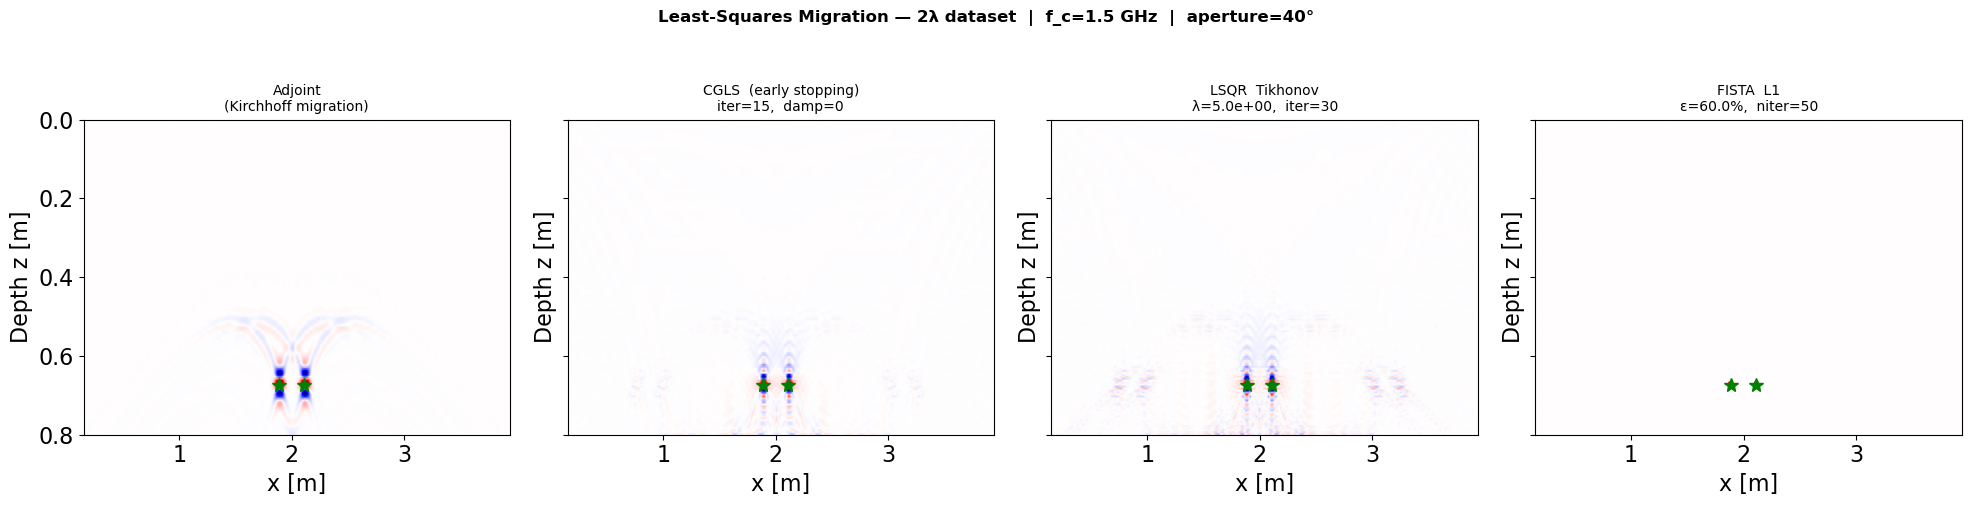

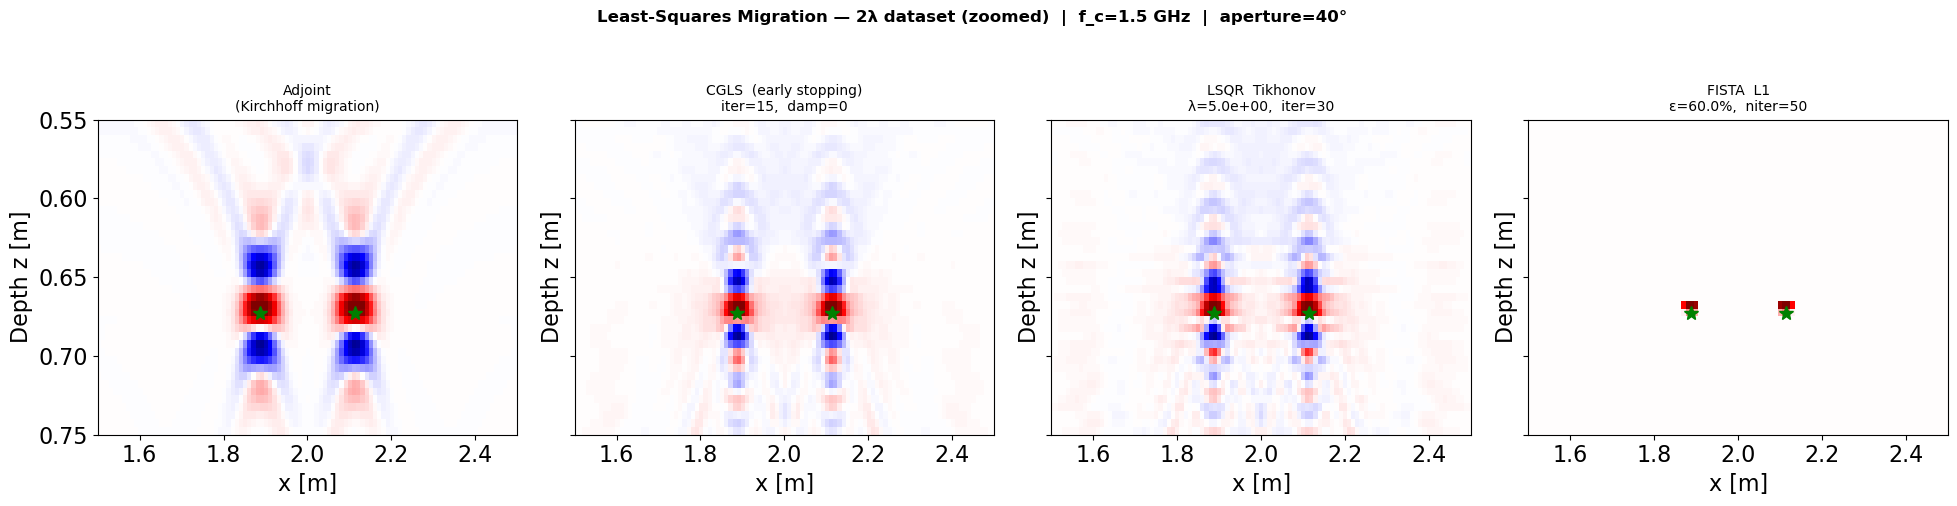

In [ ]:
x1_2lam, x2_2lam = x_s1_all[0], x_s2_all[0]

panels = [
    (m_adj,   'Adjoint\n(Kirchhoff migration)'),
    (m_cgls,  f'CGLS  (early stopping)\niter={ITER_OPT},  damp=0'),
    (m_lsqr,  f'LSQR  Tikhonov\nλ={DAMP_OPT:.1e},  iter={LSQR_FINAL_ITERS}'),
    (m_fista, f'FISTA  L1\nε={EPS_FRAC_OPT*100:.1f}%,  niter={FISTA_FINAL_ITERS}'),
]

for xlim, zlim, tag in [
    ((x_traces[0], x_traces[-1]), (z_img[-1], z_img[0]), ''),
    ((1.5, 2.5),                   (0.75, 0.55),          '_zoomed'),
]:
    fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
    for ax, (img, title) in zip(axes, panels):
        vmax = np.max(np.abs(img)) * 0.8
        ax.imshow(img, aspect='auto', cmap='seismic', vmin=-vmax, vmax=vmax,
                  extent=extent_mig, origin='upper')
        ax.plot([x1_2lam, x2_2lam], [z_top, z_top], 'g*', ms=10, zorder=5)
        ax.set_xlim(*xlim); ax.set_ylim(*zlim)
        ax.set_title(title, fontsize=10)
        ax.set_xlabel('x [m]'); ax.set_ylabel('Depth z [m]')

    zoom = ' (zoomed)' if tag else ''
    plt.suptitle(
        f'Least-Squares Migration — 2λ dataset{zoom}  |  f_c={f_c_GHz} GHz  |  aperture={ANGLE_AP}°',
        fontsize=12, fontweight='bold', y=1.02
    )
    plt.tight_layout()
    plt.savefig(STUDY_ROOT / f'lsm_2lambda{tag}.png', dpi=150, bbox_inches='tight')
    plt.show()

# Image Domain Least-Squares Migration (ILSM)

Instead of repeatedly applying the full forward/adjoint Kirchhoff operator, ILSM
approximates the **Hessian** H = K^H K directly in the image domain:

> **m** = H **r**  →  H ≈ NonStationaryConvolve2D

**Steps:**
1. Place a grid of point scatterers (PSF reflectivity)
2. Forward-model + migrate: `d_psf = K @ psf_refl`, `m_psf = K.H @ d_psf` (2 matvecs total)
3. Extract local PSF patches from `m_psf` — each patch is the spatially-varying impulse response
4. Build `Cop` (PyLops `NonStationaryConvolve2D`) as the Hessian approximation
5. Invert `Cop @ r = m_adj` with FISTA — **no further K applications**


PSF grid: 12 x 7 = 84 points  patch size: 31x21
Forward modelling PSF reflectivity ...
  Forward done in 0.2 s
  Migration done in 0.6 s
PSF patches extracted  shape: (12, 7, 31, 21)


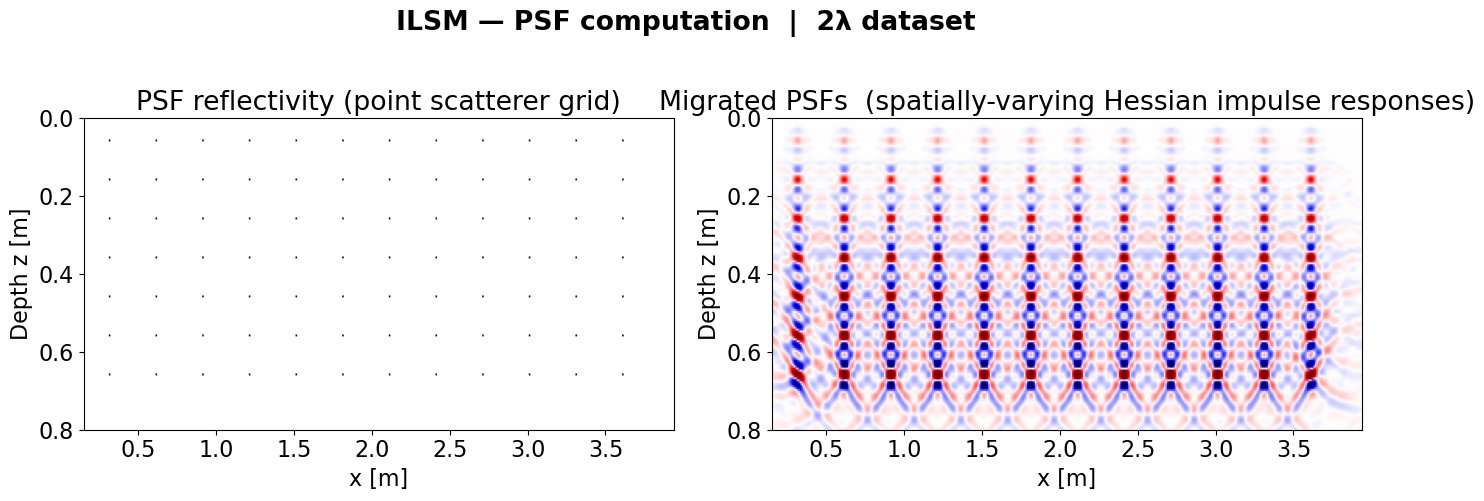

In [ ]:
# ── PSF grid parameters ──────────────────────────────────────────────────────
n_x_img, n_z_img = len(x_traces), len(z_img)   # 380, 160
PSFSIZE   = (31, 21)   # patch half-size (x, z) pixels — must fit inside image
PSFJ      = (30, 20)   # PSF grid spacing (x, z) pixels
PSFMARGIN = (PSFSIZE[0]//2 + 1, PSFSIZE[1]//2 + 1)   # boundary clearance

psfx_idx = np.arange(PSFMARGIN[0], n_x_img - PSFMARGIN[0], PSFJ[0])
psfz_idx = np.arange(PSFMARGIN[1], n_z_img - PSFMARGIN[1], PSFJ[1])
print(f'PSF grid: {len(psfx_idx)} x {len(psfz_idx)} = {len(psfx_idx)*len(psfz_idx)} points'
      f'  patch size: {PSFSIZE[0]}x{PSFSIZE[1]}')

# PSF reflectivity in K's (nx, nz) model convention
psf_refl_nxnz = np.zeros((n_x_img, n_z_img))
for _ix in psfx_idx:
    for _iz in psfz_idx:
        psf_refl_nxnz[_ix, _iz] = 1.0

# ── Forward model + migrate (2 K-applications total) ─────────────────────────
print('Forward modelling PSF reflectivity ...')
t0 = _time.perf_counter()
d_psf      = lsm_K @ psf_refl_nxnz.ravel()                        # (n_tr x n_t)
print(f'  Forward done in {_time.perf_counter()-t0:.1f} s')
t0 = _time.perf_counter()
m_psf_nxnz = (lsm_K.H @ d_psf).reshape(n_x_img, n_z_img)          # (nx, nz)
print(f'  Migration done in {_time.perf_counter()-t0:.1f} s')

# ── Extract PSF patches ───────────────────────────────────────────────────────
psfs = np.zeros((len(psfx_idx), len(psfz_idx), *PSFSIZE))
hw_x, hw_z = PSFSIZE[0]//2, PSFSIZE[1]//2
for ipx, px in enumerate(psfx_idx):
    for ipz, pz in enumerate(psfz_idx):
        psfs[ipx, ipz] = m_psf_nxnz[
            px - hw_x : px + hw_x + 1,
            pz - hw_z : pz + hw_z + 1,
        ]
print(f'PSF patches extracted  shape: {psfs.shape}')

# ── Plot: PSF reflectivity and migrated PSF image ─────────────────────────────
extent_mig = [x_traces[0], x_traces[-1], z_img[-1], z_img[0]]
fig, axes  = plt.subplots(1, 2, figsize=(14, 5))

axes[0].imshow(psf_refl_nxnz.T, aspect='auto', cmap='gray_r',
               extent=extent_mig, origin='upper')
axes[0].set(title='PSF reflectivity (point scatterer grid)',
            xlabel='x [m]', ylabel='Depth z [m]')

vmax_psf = np.percentile(np.abs(m_psf_nxnz), 99)
axes[1].imshow(m_psf_nxnz.T, aspect='auto', cmap='seismic',
               vmin=-vmax_psf, vmax=vmax_psf, extent=extent_mig, origin='upper')
axes[1].set(title='Migrated PSFs  (spatially-varying Hessian impulse responses)',
            xlabel='x [m]', ylabel='Depth z [m]')

plt.suptitle('ILSM — PSF computation  |  2λ dataset', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(STUDY_ROOT / 'ilsm_psfs.png', dpi=150, bbox_inches='tight')
plt.show()


Cop shape: (60800, 60800)
Running FISTA (eps=1e+03, niter=100) ...
Done in 7.4 s


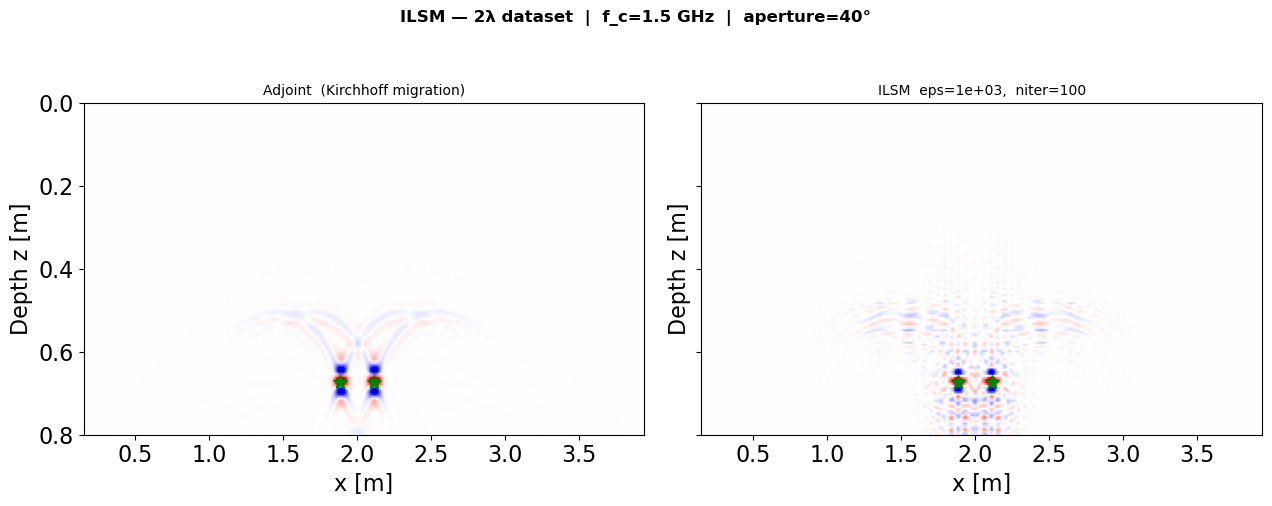

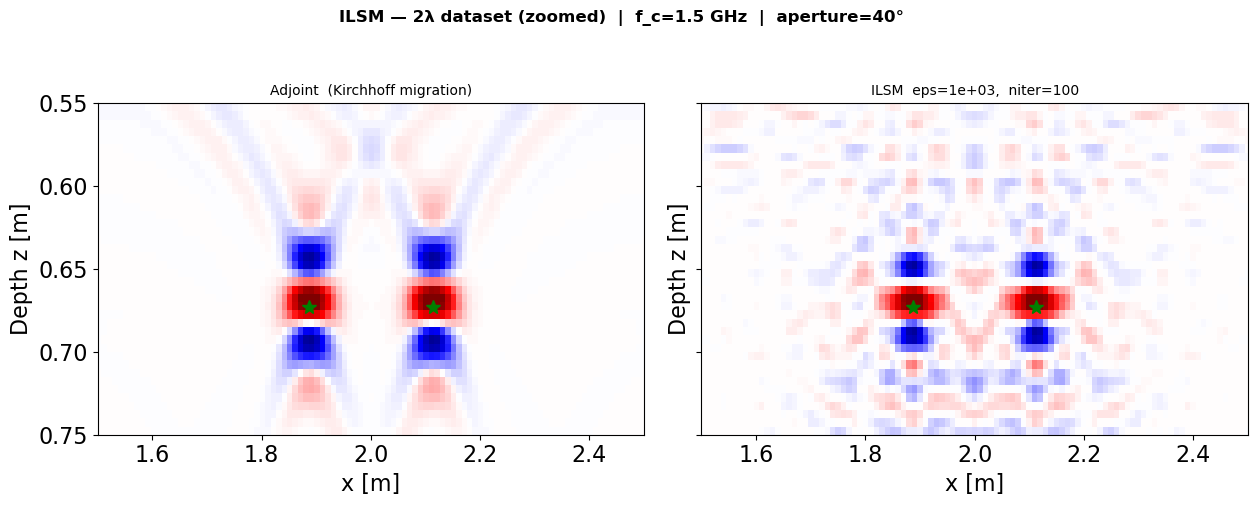

In [ ]:
# ── Build NonStationaryConvolve2D Hessian approximation ──────────────────────
Cop = pylops.signalprocessing.NonStationaryConvolve2D(
    hs=psfs, ihx=psfx_idx, ihz=psfz_idx,
    dims=(n_x_img, n_z_img), engine='numba'
)
print(f'Cop shape: {Cop.shape}')

# ── FISTA inversion: solve Cop @ r = m_adj ────────────────────────────────────
# m_adj is (nz, nx); K's model convention is (nx, nz) → transpose before passing
m_adj_nxnz = m_adj.T   # (nx, nz)
EPS_ILSM   = 1e3        # regularisation strength — increase for sparser result

print(f'Running FISTA (eps={EPS_ILSM:.0e}, niter=100) ...')
t0 = _time.perf_counter()
m_ilsm_vec, _, _ = pylops.optimization.sparsity.fista(
    Cop, m_adj_nxnz.ravel(), eps=EPS_ILSM, niter=100,
    eigsdict=dict(niter=5, tol=1e-2), show=False
)
m_ilsm = m_ilsm_vec.reshape(n_x_img, n_z_img).T   # back to (nz, nx)
print(f'Done in {_time.perf_counter()-t0:.1f} s')

# ── Plot: adjoint vs ILSM ─────────────────────────────────────────────────────
x1_2lam, x2_2lam = x_s1_all[0], x_s2_all[0]
panels = [
    (m_adj,  'Adjoint  (Kirchhoff migration)'),
    (m_ilsm, f'ILSM  eps={EPS_ILSM:.0e},  niter=100'),
]

for xlim, zlim, tag in [
    ((x_traces[0], x_traces[-1]), (z_img[-1], z_img[0]), ''),
    ((1.5, 2.5),                   (0.75, 0.55),          '_zoomed'),
]:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
    for ax, (img, title) in zip(axes, panels):
        vmax = np.max(np.abs(img)) * 0.8
        ax.imshow(img, aspect='auto', cmap='seismic', vmin=-vmax, vmax=vmax,
                  extent=extent_mig, origin='upper')
        ax.plot([x1_2lam, x2_2lam], [z_top, z_top], 'g*', ms=10, zorder=5)
        ax.set_xlim(*xlim); ax.set_ylim(*zlim)
        ax.set_title(title, fontsize=10)
        ax.set_xlabel('x [m]'); ax.set_ylabel('Depth z [m]')
    zoom = ' (zoomed)' if tag else ''
    plt.suptitle(
        f'ILSM — 2λ dataset{zoom}  |  f_c={f_c_GHz} GHz  |  aperture={ANGLE_AP}°',
        fontsize=12, fontweight='bold', y=1.02
    )
    plt.tight_layout()
    plt.savefig(STUDY_ROOT / f'ilsm_2lambda{tag}.png', dpi=150, bbox_inches='tight')
    plt.show()


# Back-Propagation Migration

Time-reversal migration: re-inject the time-reversed, normalised B-scan traces at the
original receiver positions through a **half-velocity medium** (eps_r × 4 so v → v_ice/2).

Under the exploding-reflector hypothesis every scatterer focuses simultaneously at

> **t_focus = T − t0_ns**

where T is the total simulation window. Snapshots are captured in a narrow window just
before t_focus so the collapsed wavefield image can be extracted.

| Parameter | Value |
|-----------|-------|
| Injection positions | Rx locations (Tx + 0.1 m offset) |
| Medium | eps_r × 4 → v = v_ice / 2 |
| Source stride | every `STRIDE`-th trace (tunes performance vs coverage) |

In [26]:
# ── Parameters ──────────────────────────────────────────────────────
# For zero-offset backpropagation with v_mig = v/2 (exploding-reflector),
# sources must be placed at the Tx-Rx MIDPOINTS, not at the Rx positions.
# Using Rx positions (offset +0.05 m) while keeping half-velocity causes a
# systematic lateral shift of rx_offset/2 in the focused image.
slugs  = ['2lambda', '1lambda', '0p5lambda', '0p25lambda', '0p125lambda', '0p0625lambda']
STRIDE   = 1    # use every Nth trace — reduces gprMax source count
N_SNAP   = 30   # number of snapshots in the focus window
SNAP_WIN = 1.0  # [ns] window before focus time to capture

def write_backprop_files(label, slug, tapered_ntr_nt, dt_ns, x_midpoints):
    """
    Write gprMax excitation file and .in file for back-propagation migration.
    Files go in STUDY_ROOT/backprop/<slug>/.

    Sources are placed at the Tx-Rx midpoints (x_traces), consistent with the
    exploding-reflector half-velocity (v_mig = v/2) assumption: the data is
    attributed to the midpoint, so injecting there + using v/2 focuses the
    wavefield at the true scatterer positions without lateral offset.

    Returns (in_path, n_src, n_snaps, t_focus_ns).
    """
    out_dir = STUDY_ROOT / 'backprop' / slug
    out_dir.mkdir(parents=True, exist_ok=True)

    n_tr, n_t = tapered_ntr_nt.shape
    dt_s  = dt_ns * 1e-9
    T_ns  = n_t * dt_ns

    # Stride, time-reverse, normalise per trace
    data_s   = tapered_ntr_nt[::STRIDE]
    x_src    = x_midpoints[::STRIDE]   # midpoints, NOT Rx positions
    n_src    = len(x_src)
    data_rev = data_s[:, ::-1].copy()
    peak     = np.max(np.abs(data_rev), axis=1, keepdims=True)
    peak[peak == 0] = 1.0
    data_rev /= peak

    # Snapshot timing: all depths focus simultaneously at t_focus = T - t0
    t_focus_ns = T_ns - t0_ns
    t_start_ns = max(0.0, t_focus_ns - SNAP_WIN)
    t_start_s  = t_start_ns * 1e-9
    snap_step  = max(1, int((T_ns * 1e-9 - t_start_s) / (max(1, N_SNAP - 1) * dt_s)))
    n_snaps    = max(1, int((n_t * dt_s - t_start_s) / (snap_step * dt_s)))

    # Excitation file: rows = time steps, cols = [time, src_0, ..., src_n]
    exc_path = out_dir / 'excitation.txt'
    time_s   = np.arange(n_t) * dt_s
    N_PAD    = 10
    pad_t    = np.arange(n_t, n_t + N_PAD) * dt_s
    exc_arr  = np.vstack([
        np.column_stack([time_s, data_rev.T]),
        np.column_stack([pad_t,  np.zeros((N_PAD, n_src))]),
    ])
    header = 'time ' + ' '.join(f'bp_{i}' for i in range(n_src))
    np.savetxt(exc_path, exc_arr, fmt='%.6e', header=header, comments='')

    # Source x-positions (loaded at gprMax runtime)
    npy_path = out_dir / 'src_positions.npy'
    np.save(npy_path, x_src)

    # Write .in file
    EPS_R_HALF = 4.0 * eps_r
    v_half     = v_ice / 2
    in_path    = out_dir / f'backprop_{slug}.in'

    in_lines = [
        f'#title: Back-Propagation -- {label} separation',
        '#domain: 4.000 1.000 0.001',
        '#dx_dy_dz: 0.001 0.001 0.001',
        f'#time_window: {n_t * dt_s:.6e}',
        '#pml_cells: 10 10 0 10 10 0',
        '',
        f'// Half-velocity: eps_r={EPS_R_HALF:.2f} (=4x{eps_r}) -> v={v_half:.5f} m/ns',
        f'#material: {EPS_R_HALF:.2f} 1e-6 1.0 0 ice',
        '',
        f'#box: 0 0 0 4.000 0.900 0.001 ice',
        '',
        f'#excitation_file: {exc_path.name}',
        '',
        f'// {n_src} time-reversed sources at Tx-Rx midpoints (zero-offset convention, stride={STRIDE})',
        '#python:',
        'from gprMax.input_cmd_funcs import *',
        'import numpy as np',
        f"x_sources = np.load(r'{npy_path}')",
        'for i, x in enumerate(x_sources):',
        "    hertzian_dipole('z', float(x), 0.900, 0.0, 'bp_{}'.format(i))",
        '#end_python:',
        '',
        f'// {n_snaps} snapshots  window=[{t_start_ns:.1f}, {T_ns:.1f}] ns  focus at {t_focus_ns:.2f} ns',
        '#python:',
        'from gprMax.input_cmd_funcs import *',
        f't_start = {t_start_s:.8e}',
        f'step    = {snap_step}',
        f'dt_gpr  = {dt_s:.8e}',
        f'n_snap  = {n_snaps}',
        'for k in range(n_snap):',
        '    t_snap = t_start + k * step * dt_gpr',
        "    print('#snapshot: 0 0 0 4.000 1.000 0.001 0.001 0.001 0.001 %.8e bp_snap%04d' % (t_snap, k+1))",
        '#end_python:',
        '',
        '#messages: y',
    ]
    in_path.write_text('\n'.join(in_lines) + '\n')
    return in_path, n_src, n_snaps, t_focus_ns

# ── Generate files for all 6 datasets ────────────────────────────────────────────
print(f'Back-propagation file generation  (stride={STRIDE}, {N_SNAP} snapshots)\n')
bp_paths = {}
for label, slug, raw in zip(labels, slugs, outputs):
    tapered, _ = preprocess(raw, dt_ns, t0_ns, time_ns)
    in_path, n_src, n_snaps, t_focus = write_backprop_files(
        label, slug, tapered, dt_ns, x_traces   # x_traces = midpoints
    )
    bp_paths[label] = in_path
    exc_mb = (in_path.parent / 'excitation.txt').stat().st_size / 1e6
    print(f'  [{label}]  {n_src} sources  |  {n_snaps} snapshots  |  '
          f'focus={t_focus:.2f} ns  |  excitation={exc_mb:.1f} MB')
    print(f'           {in_path}')


Back-propagation file generation  (stride=1, 30 snapshots)

  [2λ]  380 sources  |  29 snapshots  |  focus=19.06 ns  |  excitation=42.7 MB
           C:\Users\Administrator\OneDrive\Thesis\TimeLapse_Notebooks\resolution_study\backprop\2lambda\backprop_2lambda.in
  [1λ]  380 sources  |  29 snapshots  |  focus=19.06 ns  |  excitation=42.6 MB
           C:\Users\Administrator\OneDrive\Thesis\TimeLapse_Notebooks\resolution_study\backprop\1lambda\backprop_1lambda.in
  [½λ]  380 sources  |  29 snapshots  |  focus=19.06 ns  |  excitation=42.5 MB
           C:\Users\Administrator\OneDrive\Thesis\TimeLapse_Notebooks\resolution_study\backprop\0p5lambda\backprop_0p5lambda.in
  [¼λ]  380 sources  |  29 snapshots  |  focus=19.06 ns  |  excitation=42.5 MB
           C:\Users\Administrator\OneDrive\Thesis\TimeLapse_Notebooks\resolution_study\backprop\0p25lambda\backprop_0p25lambda.in
  [⅛λ]  380 sources  |  29 snapshots  |  focus=19.06 ns  |  excitation=42.5 MB
           C:\Users\Administrator\OneDr

[2λ]  29 snaps  |  focus idx=19  t=19.316 ns
[1λ]  29 snaps  |  focus idx=19  t=19.316 ns
[½λ]  29 snaps  |  focus idx=19  t=19.316 ns
[¼λ]  29 snaps  |  focus idx=19  t=19.316 ns
[⅛λ]  29 snaps  |  focus idx=19  t=19.316 ns
[¹⁄₁₆λ]  29 snaps  |  focus idx=19  t=19.316 ns


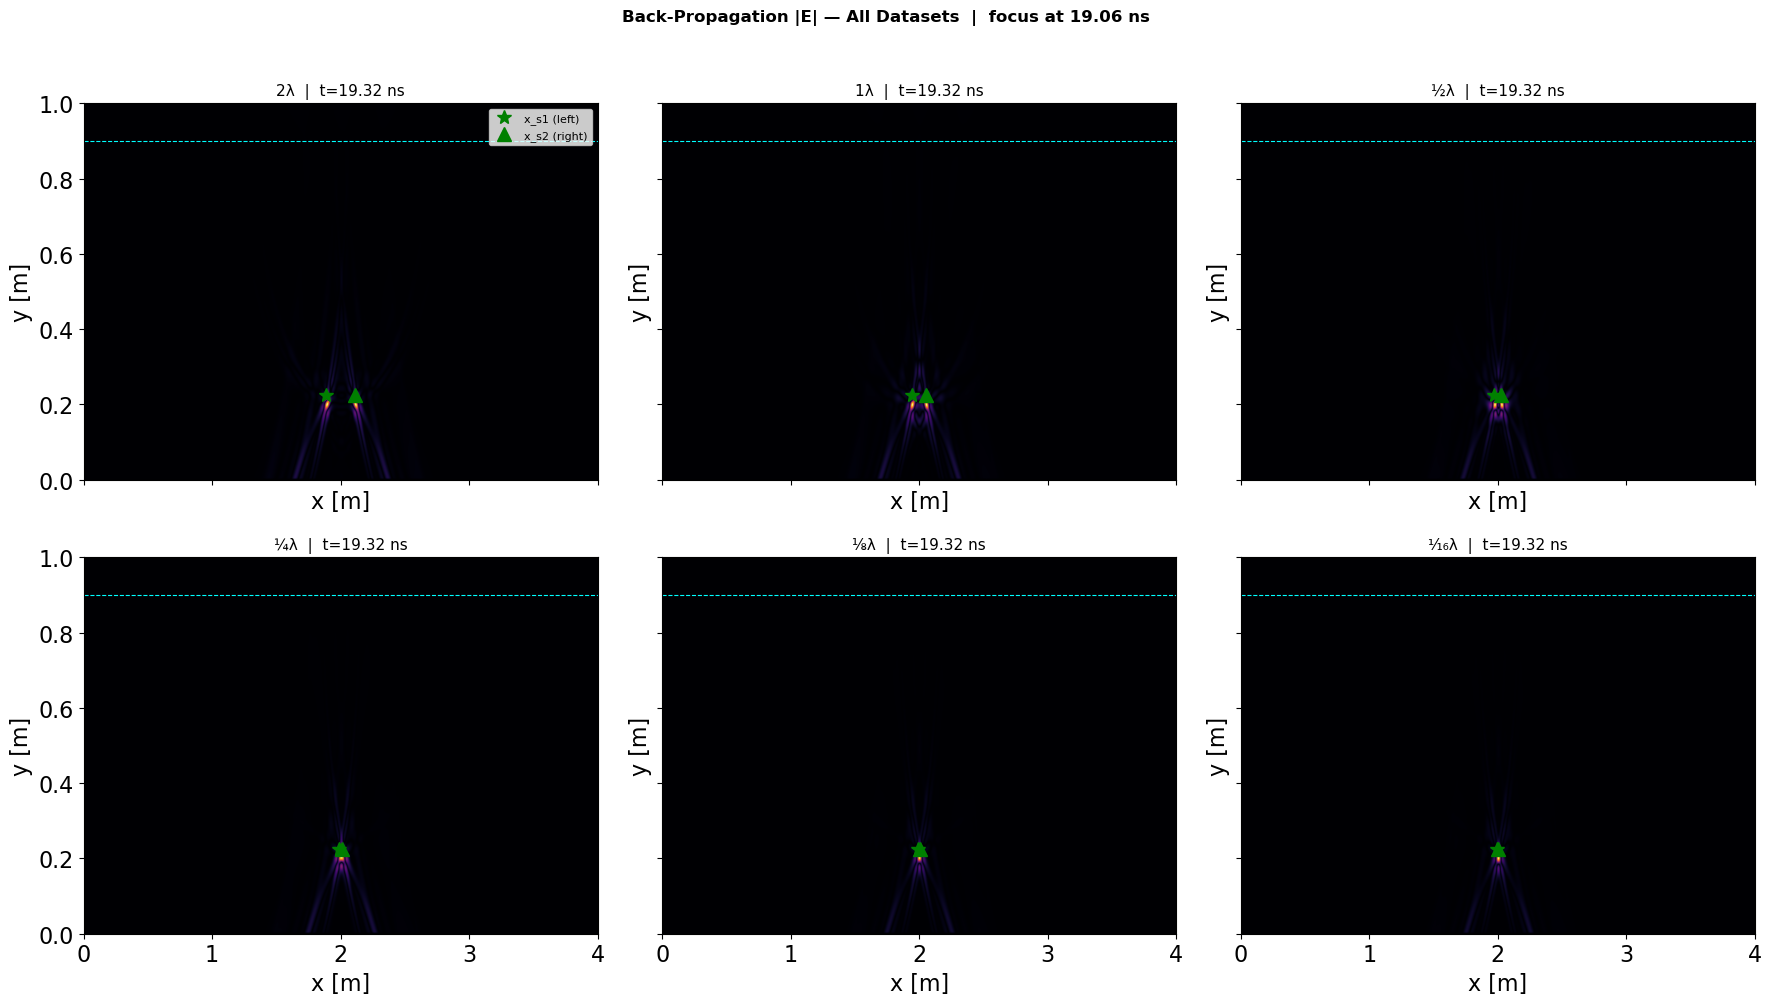

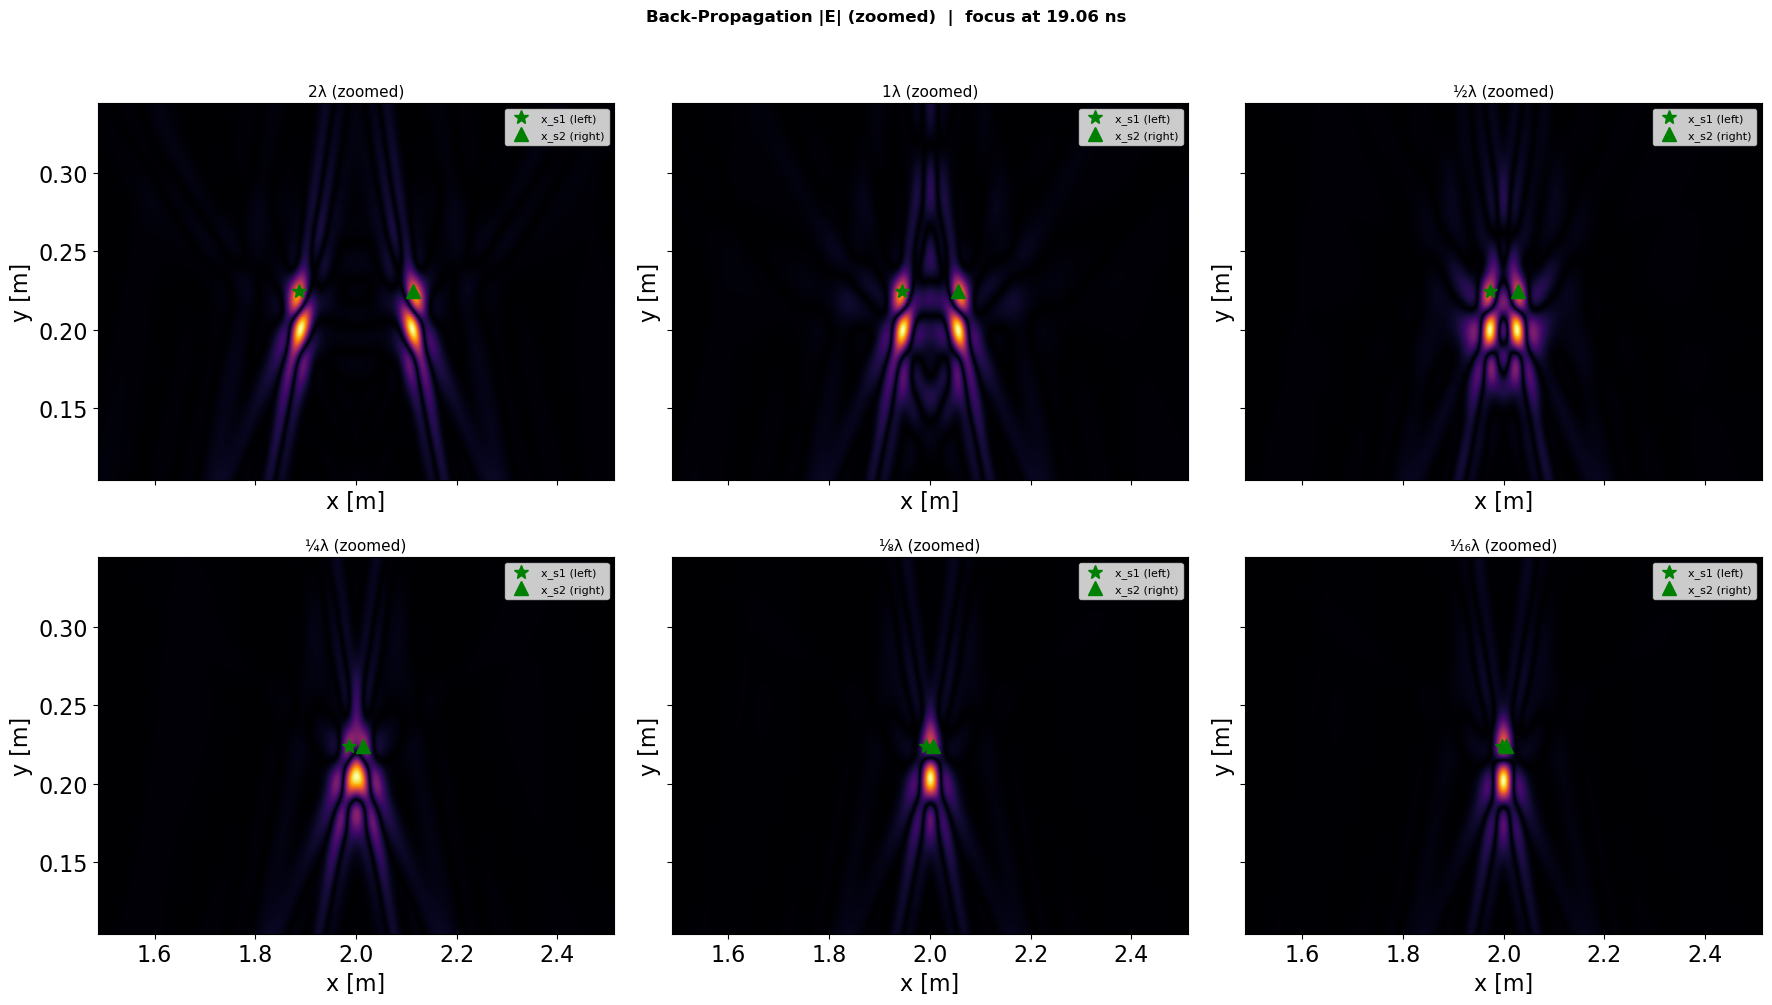

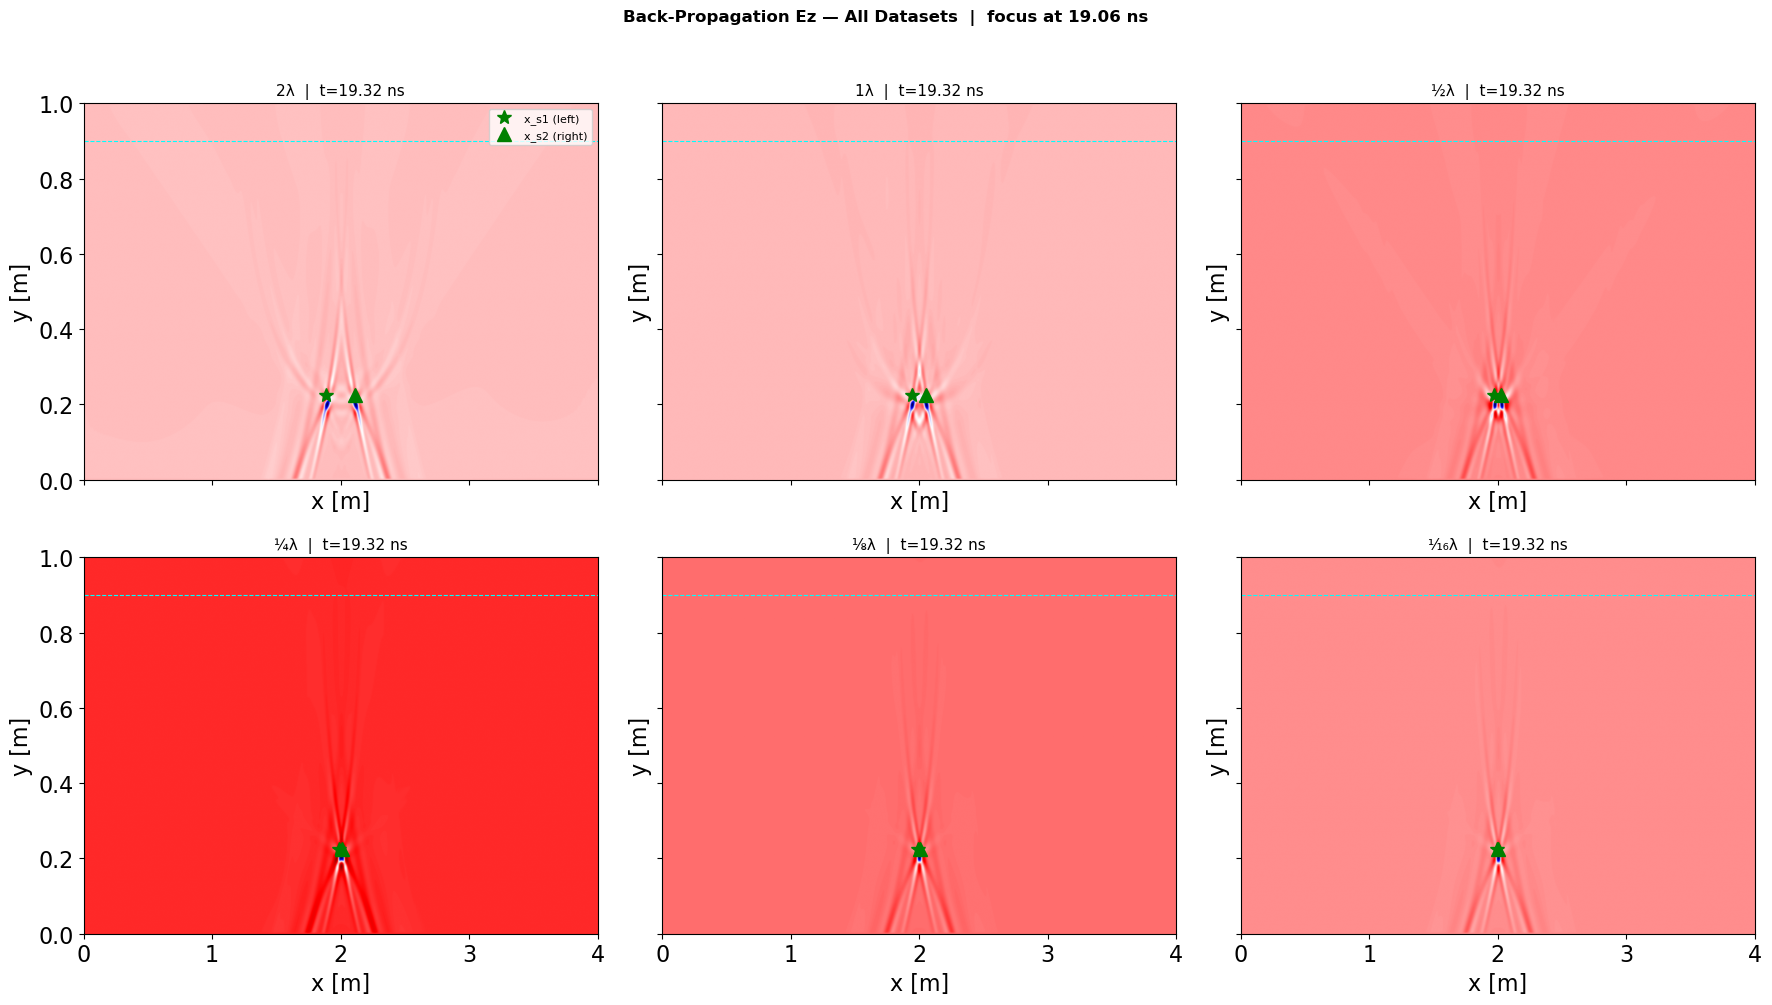

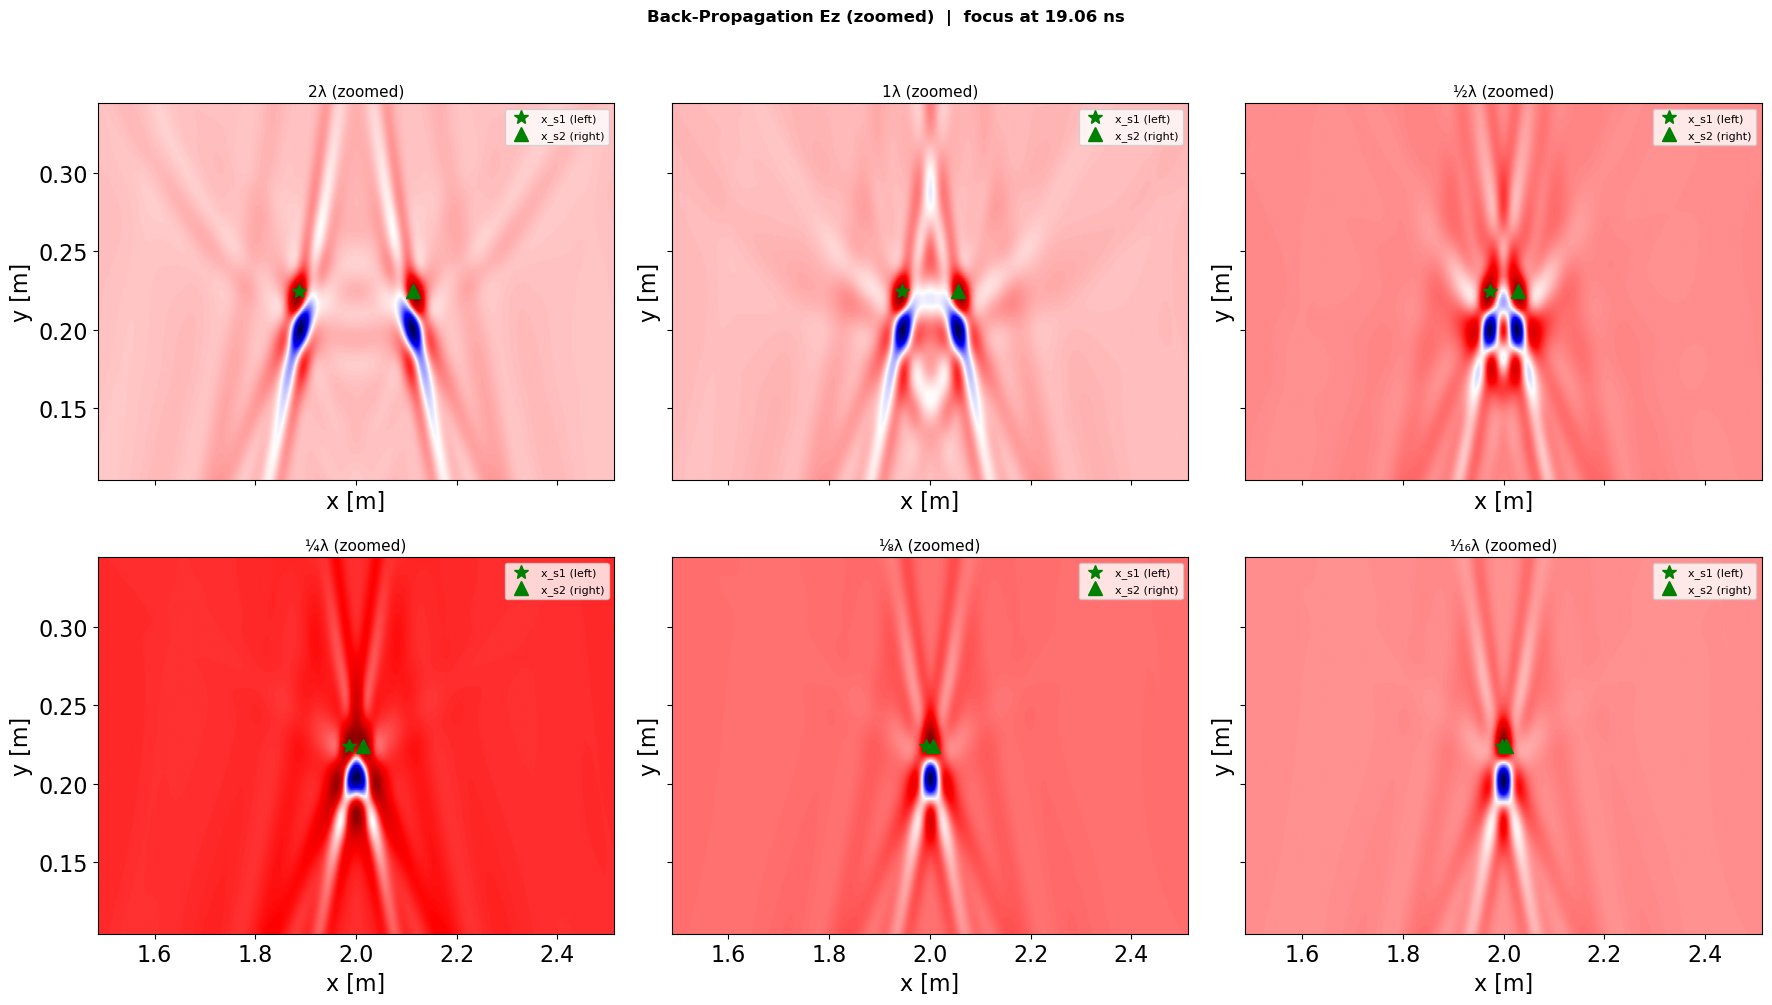

In [47]:
import pyvista

# ── Load focus frame for all 6 datasets ────────────────────────────────────────
T_ns_bp    = n_t * dt_ns
t_focus_ns = T_ns_bp - t0_ns
t_start_ns = max(0.0, t_focus_ns - SNAP_WIN)
dt_s       = dt_ns * 1e-9
snap_step_ref = max(1, int((T_ns_bp*1e-9 - t_start_ns*1e-9) / (max(1, N_SNAP - 1) * dt_s)))

focus_frames = {}
for i, (label, slug) in enumerate(zip(labels, slugs)):
    snap_dir   = STUDY_ROOT / 'backprop' / slug / f'backprop_{slug}_snaps'
    snap_files = sorted(
        snap_dir.glob('bp_snap*.vti'),
        key=lambda p: int(p.stem.replace('bp_snap', ''))
    )
    if not snap_files:
        print(f'[{label}] No snapshots in {snap_dir.name} — skipping')
        continue

    snap_times_ns = t_start_ns + np.arange(len(snap_files)) * snap_step_ref * dt_ns
    idx_focus     = min(int(np.argmin(np.abs(snap_times_ns - t_focus_ns))) + 4,
                        len(snap_files) - 1)

    # Derive grid dimensions from the first snapshot (avoids hardcoding)
    Nx_bp = Ny_bp = None
    snaps_mag, snaps_ez = [], []
    for p in snap_files:
        mesh   = pyvista.read(str(p))
        e_data = np.array(mesh['E-field'])
        if Nx_bp is None:
            Nx_bp = mesh.dimensions[0] - 1   # cells in x (= domain_x / dx = 4000)
            Ny_bp = mesh.dimensions[1] - 1   # cells in y (= domain_y / dy = 1000)
        snaps_mag.append(np.linalg.norm(e_data, axis=1).reshape(Ny_bp, Nx_bp))
        snaps_ez.append(e_data[:, 2].reshape(Ny_bp, Nx_bp))

    focus_frames[label] = {
        'mag':      np.stack(snaps_mag)[idx_focus],
        'ez':       np.stack(snaps_ez)[idx_focus],
        't_actual': snap_times_ns[idx_focus],
        'i':        i,
    }
    print(f'[{label}]  {len(snap_files)} snaps  |  focus idx={idx_focus}'
          f'  t={focus_frames[label]["t_actual"]:.3f} ns')

extent_full = [0, 4.0, 0, 1]
margin_x    = 0.4
margin_y    = 0.12

# Zoom x-window fixed to cover the widest (2λ) shift in all shared-axis panels
x_zoom_lo = x_scatterer_1[0] - margin_x
x_zoom_hi = x_scatterer_2[0] + margin_x   # right scatterer of 2λ (widest) separation

def _add_markers(ax, i):
    ax.plot(x_scatterer_1[i], y_scatterer, 'g*', ms=10, zorder=5, label='x_s1 (left)')
    ax.plot(x_scatterer_2[i], y_scatterer, 'g^', ms=10, zorder=5, label='x_s2 (right)')

# ── |E| magnitude — full extent 2×3 grid ──────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)
for ax, (label, frame) in zip(axes.ravel(), focus_frames.items()):
    vmax = np.percentile(frame['mag'], 99.5)
    ax.imshow(frame['mag'], aspect='auto', cmap='inferno',
              extent=extent_full, origin='lower')
    _add_markers(ax, frame['i'])
    ax.axhline(y_surface, color='cyan', lw=0.8, ls='--')
    ax.set_title(f'{label}  |  t={frame["t_actual"]:.2f} ns', fontsize=11)
    ax.set_xlabel('x [m]'); ax.set_ylabel('y [m]')
axes.ravel()[0].legend(fontsize=8, loc='upper right')
plt.suptitle(f'Back-Propagation |E| — All Datasets  |  focus at {t_focus_ns:.2f} ns',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(STUDY_ROOT / 'backprop_all_mag_full.png', dpi=150, bbox_inches='tight')
plt.show()

# ── |E| magnitude — zoomed 2×3 grid ──────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)
for ax, (label, frame) in zip(axes.ravel(), focus_frames.items()):
    vmax = np.percentile(frame['mag'], 99.5)
    ax.imshow(frame['mag'], aspect='auto', cmap='inferno',
              extent=extent_full, origin='lower')
    _add_markers(ax, frame['i'])
    ax.set_xlim(x_zoom_lo, x_zoom_hi)
    ax.set_ylim(y_scatterer - margin_y, y_scatterer + margin_y)
    ax.set_title(f'{label} (zoomed)', fontsize=11)
    ax.set_xlabel('x [m]'); ax.set_ylabel('y [m]')
    ax.legend(fontsize=8, loc='upper right')
plt.suptitle(f'Back-Propagation |E| (zoomed)  |  focus at {t_focus_ns:.2f} ns',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(STUDY_ROOT / 'backprop_all_mag_zoomed.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Ez component — full extent 2×3 grid ──────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)
for ax, (label, frame) in zip(axes.ravel(), focus_frames.items()):
    vmax = np.percentile(np.abs(frame['ez']), 99.5)
    ax.imshow(frame['ez'], aspect='auto', cmap='seismic',
              extent=extent_full, origin='lower')
    _add_markers(ax, frame['i'])
    ax.axhline(y_surface, color='cyan', lw=0.8, ls='--')
    ax.set_title(f'{label}  |  t={frame["t_actual"]:.2f} ns', fontsize=11)
    ax.set_xlabel('x [m]'); ax.set_ylabel('y [m]')
axes.ravel()[0].legend(fontsize=8, loc='upper right')
plt.suptitle(f'Back-Propagation Ez — All Datasets  |  focus at {t_focus_ns:.2f} ns',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(STUDY_ROOT / 'backprop_all_ez_full.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Ez component — zoomed 2×3 grid ───────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)
for ax, (label, frame) in zip(axes.ravel(), focus_frames.items()):
    vmax = np.percentile(np.abs(frame['ez']), 99.5)
    ax.imshow(frame['ez'], aspect='auto', cmap='seismic',
              extent=extent_full, origin='lower')
    _add_markers(ax, frame['i'])
    ax.set_xlim(x_zoom_lo, x_zoom_hi)
    ax.set_ylim(y_scatterer - margin_y, y_scatterer + margin_y)
    ax.set_title(f'{label} (zoomed)', fontsize=11)
    ax.set_xlabel('x [m]'); ax.set_ylabel('y [m]')
    ax.legend(fontsize=8, loc='upper right')
plt.suptitle(f'Back-Propagation Ez (zoomed)  |  focus at {t_focus_ns:.2f} ns',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(STUDY_ROOT / 'backprop_all_ez_zoomed.png', dpi=150, bbox_inches='tight')
plt.show()

# Analysis

[2λ]  focus idx=19  t=19.316 ns
[1λ]  focus idx=19  t=19.316 ns
[½λ]  focus idx=19  t=19.316 ns
[¼λ]  focus idx=19  t=19.316 ns
[⅛λ]  focus idx=19  t=19.316 ns
[¹⁄₁₆λ]  focus idx=19  t=19.316 ns


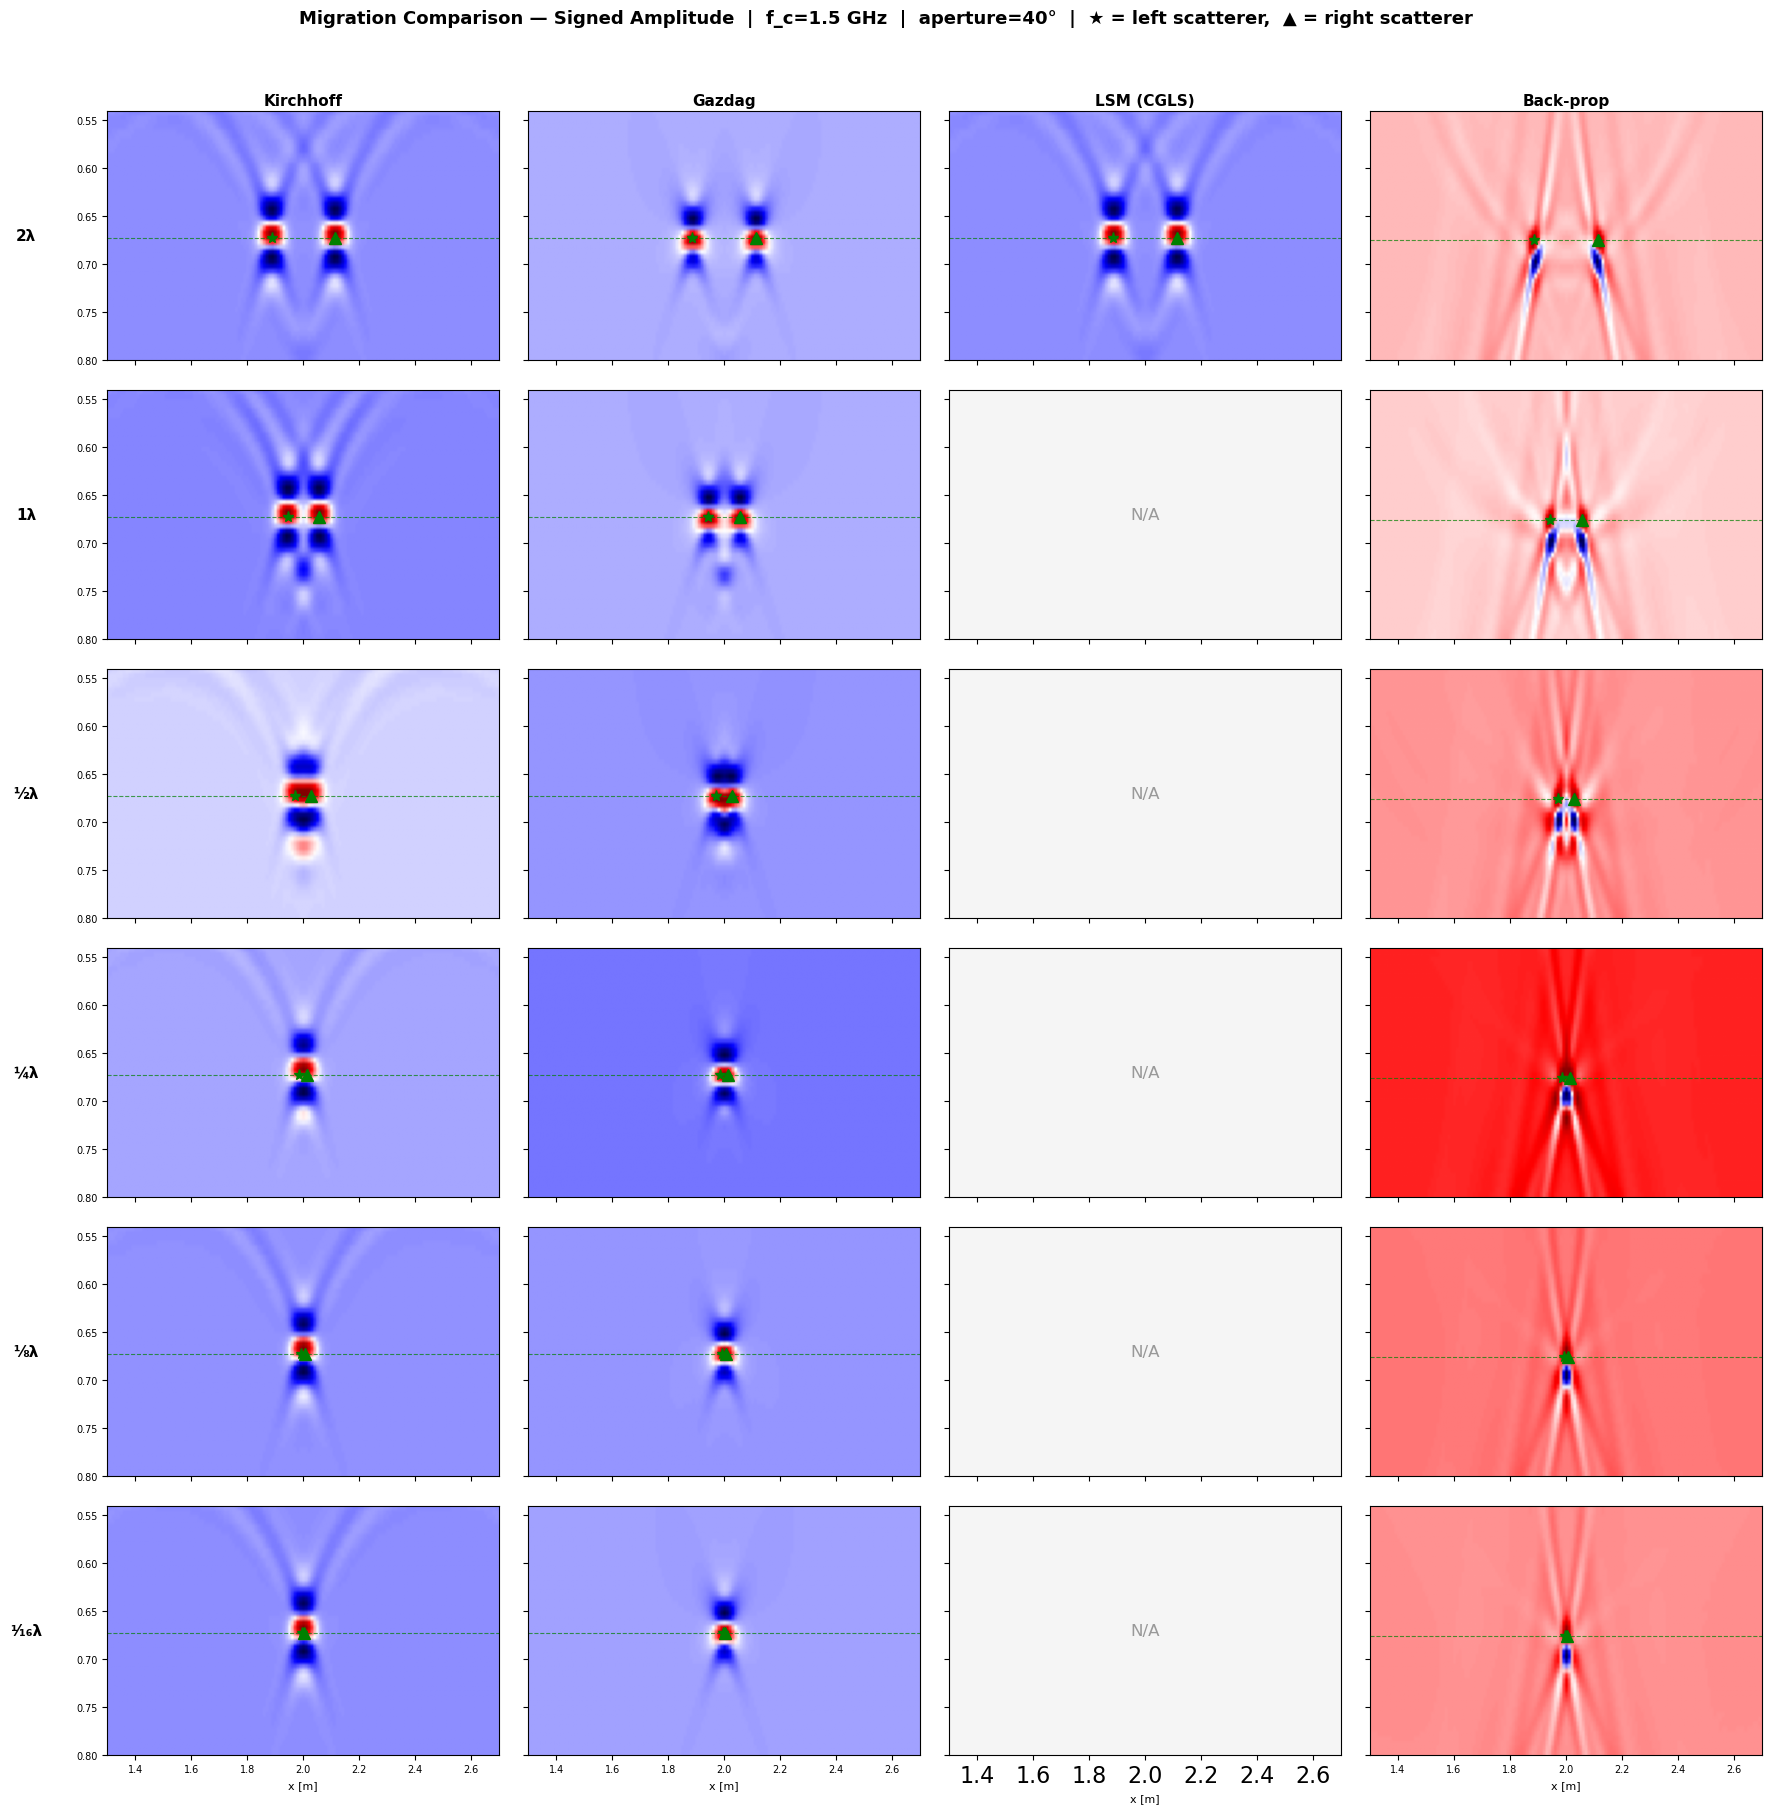

In [49]:
from scipy.signal import hilbert as scipy_hilbert
from scipy.interpolate import RegularGridInterpolator
import pyvista

# ── Collect images: rows = separations, cols = methods ───────────────────────
methods = ['Kirchhoff', 'Gazdag', 'LSM (CGLS)', 'Back-prop']
n_m, n_s = len(methods), len(labels)
imgs = [[None] * n_m for _ in range(n_s)]

for i, lbl in enumerate(labels):
    imgs[i][0] = migrated.get(lbl)
    imgs[i][1] = migrated_gz.get(lbl)

# LSM (CGLS) — 2λ only
try:
    imgs[0][2] = m_cgls
except NameError:
    try:
        imgs[0][2] = m_adj
    except NameError:
        pass

# Back-propagation — load all 6 datasets and reproject Ez to migration grid
# Back-prop snapshot grid: derive dimensions from first available VTI file
# (adapts automatically to dx=0.001 m or dx=0.002 m simulations)
Nx_bp, Ny_bp = None, None
for _slug in slugs:
    _snaps = sorted((STUDY_ROOT / "backprop" / _slug /
                     f"backprop_{_slug}_snaps").glob("bp_snap*.vti"),
                    key=lambda p: int(p.stem.replace("bp_snap", "")))
    if _snaps:
        _m0 = pyvista.read(str(_snaps[0]))
        Nx_bp = _m0.dimensions[0] - 1   # cells in x
        Ny_bp = _m0.dimensions[1] - 1   # cells in y
        break
assert Nx_bp is not None, "No back-prop snapshots found to derive grid dimensions"
x_ax_bp = np.linspace(0, 4.0, Nx_bp)   # gprMax x-axis (full domain)
y_ax_bp = np.linspace(0, 1.0, Ny_bp)   # gprMax y-axis (0=bottom, 1.0=top incl. air)
y_mig         = y_surface - z_img
Yq, Xq        = np.meshgrid(y_mig, x_traces, indexing='ij')
T_ns_bp       = n_t * dt_ns
t_focus_ns_bp = T_ns_bp - t0_ns
t_start_ns    = max(0.0, t_focus_ns_bp - SNAP_WIN)
dt_s          = dt_ns * 1e-9
snap_step_ref = max(1, int((T_ns_bp*1e-9 - t_start_ns*1e-9) / (max(1, N_SNAP - 1) * dt_s)))

for i, (lbl, slug) in enumerate(zip(labels, slugs)):
    snap_dir   = STUDY_ROOT / 'backprop' / slug / f'backprop_{slug}_snaps'
    snap_files = sorted(snap_dir.glob('bp_snap*.vti'),
                        key=lambda p: int(p.stem.replace('bp_snap', '')))
    if not snap_files:
        print(f'[{lbl}] No snapshots — skipping')
        continue

    snap_times_ns = t_start_ns + np.arange(len(snap_files)) * snap_step_ref * dt_ns
    idx_focus     = min(int(np.argmin(np.abs(snap_times_ns - t_focus_ns_bp))) + 4,
                        len(snap_files) - 1)

    snaps_ez = []
    for p in snap_files:
        mesh   = pyvista.read(str(p))
        e_data = np.array(mesh['E-field'])
        snaps_ez.append(e_data[:, 2].reshape(Ny_bp, Nx_bp))
    snaps_ez = np.stack(snaps_ez)

    interp_ez  = RegularGridInterpolator(
        (y_ax_bp, x_ax_bp), snaps_ez[idx_focus],
        method='linear', bounds_error=False, fill_value=0.0
    )
    imgs[i][3] = interp_ez((Yq, Xq))
    print(f'[{lbl}]  focus idx={idx_focus}  t={snap_times_ns[idx_focus]:.3f} ns')

# ── Scatterer depth coordinates ───────────────────────────────────────────────
# Migration: depth from surface  z_top = cylinder top
# Back-prop: gprMax domain 0-1.0 m; scatterer centre = 0.9 - y_scatterer
# Depth of scatterer centre from the ICE SURFACE (y_surface=0.9 m), not from the
# gprMax domain top (1.0 m).  Using 0.9 here is correct; 1.0 would give a depth
# 0.1 m too large (the air layer above the surface).
bp_z_top = 0.9 - y_scatterer   # = z_scatterer ≈ 0.676 m

# ── Shared plot helper ────────────────────────────────────────────────────────
extent_mig = [x_traces[0], x_traces[-1], z_img[-1], z_img[0]]
xlim = (1.3, 2.7)
ylim = (0.80, 0.54)

def _comparison_figure(envelope=False):
    fig, axes = plt.subplots(n_s, n_m, figsize=(4.5*n_m, 3.0*n_s),
                             sharex=True, sharey=True)
    for i, lbl in enumerate(labels):
        avail = [imgs[i][j] for j in range(n_m) if imgs[i][j] is not None]
        if avail:
            row_vmax = max(
                np.percentile(np.abs(np.abs(scipy_hilbert(a, axis=0)) if envelope else a), 99)
                for a in avail
            )
        else:
            row_vmax = 1.0

        for j, method in enumerate(methods):
            ax  = axes[i, j]
            img = imgs[i][j]

            if i == 0:
                ax.set_title(method, fontsize=11, fontweight='bold', pad=4)
            if j == 0:
                ax.set_ylabel(lbl, fontsize=11, fontweight='bold',
                              rotation=0, labelpad=36, va='center')
            if i == n_s - 1:
                ax.set_xlabel('x [m]', fontsize=8)

            if img is None:
                ax.text(0.5, 0.5, 'N/A', transform=ax.transAxes,
                        ha='center', va='center', fontsize=12, color='#999')
                ax.set_facecolor('#f5f5f5')
                continue

            if envelope:
                disp  = np.abs(scipy_hilbert(img, axis=0))
                cmap, vmin, vmax = 'hot', 0, row_vmax
            else:
                disp  = img
                cmap, vmin, vmax = 'seismic', -row_vmax, row_vmax

            marker_z = bp_z_top if j == 3 else z_top

            ax.imshow(disp, aspect='auto', cmap=cmap,
                      extent=extent_mig, origin='upper')
            ax.plot(x_scatterer_1[i], marker_z, 'g*', ms=8, zorder=5)
            ax.plot(x_scatterer_2[i], marker_z, 'g^', ms=8, zorder=5)
            ax.axhline(marker_z, color='green', ls='--', lw=0.8, alpha=0.7)
            ax.set_xlim(*xlim)
            ax.set_ylim(*ylim)
            ax.tick_params(labelsize=7)

    mode = 'Hilbert Envelope' if envelope else 'Signed Amplitude'
    plt.suptitle(
        f'Migration Comparison — {mode}  |  f_c={f_c_GHz} GHz  '
        f'|  aperture={ANGLE_AP}°  |  ★ = left scatterer,  ▲ = right scatterer',
        fontsize=13, fontweight='bold', y=1.01
    )
    plt.tight_layout()
    return fig

# ── Figure 1: signed amplitude ────────────────────────────────────────────────
fig1 = _comparison_figure(envelope=False)
fig1.savefig(STUDY_ROOT / 'comparison_all_methods.png', dpi=250, bbox_inches='tight')
plt.show()


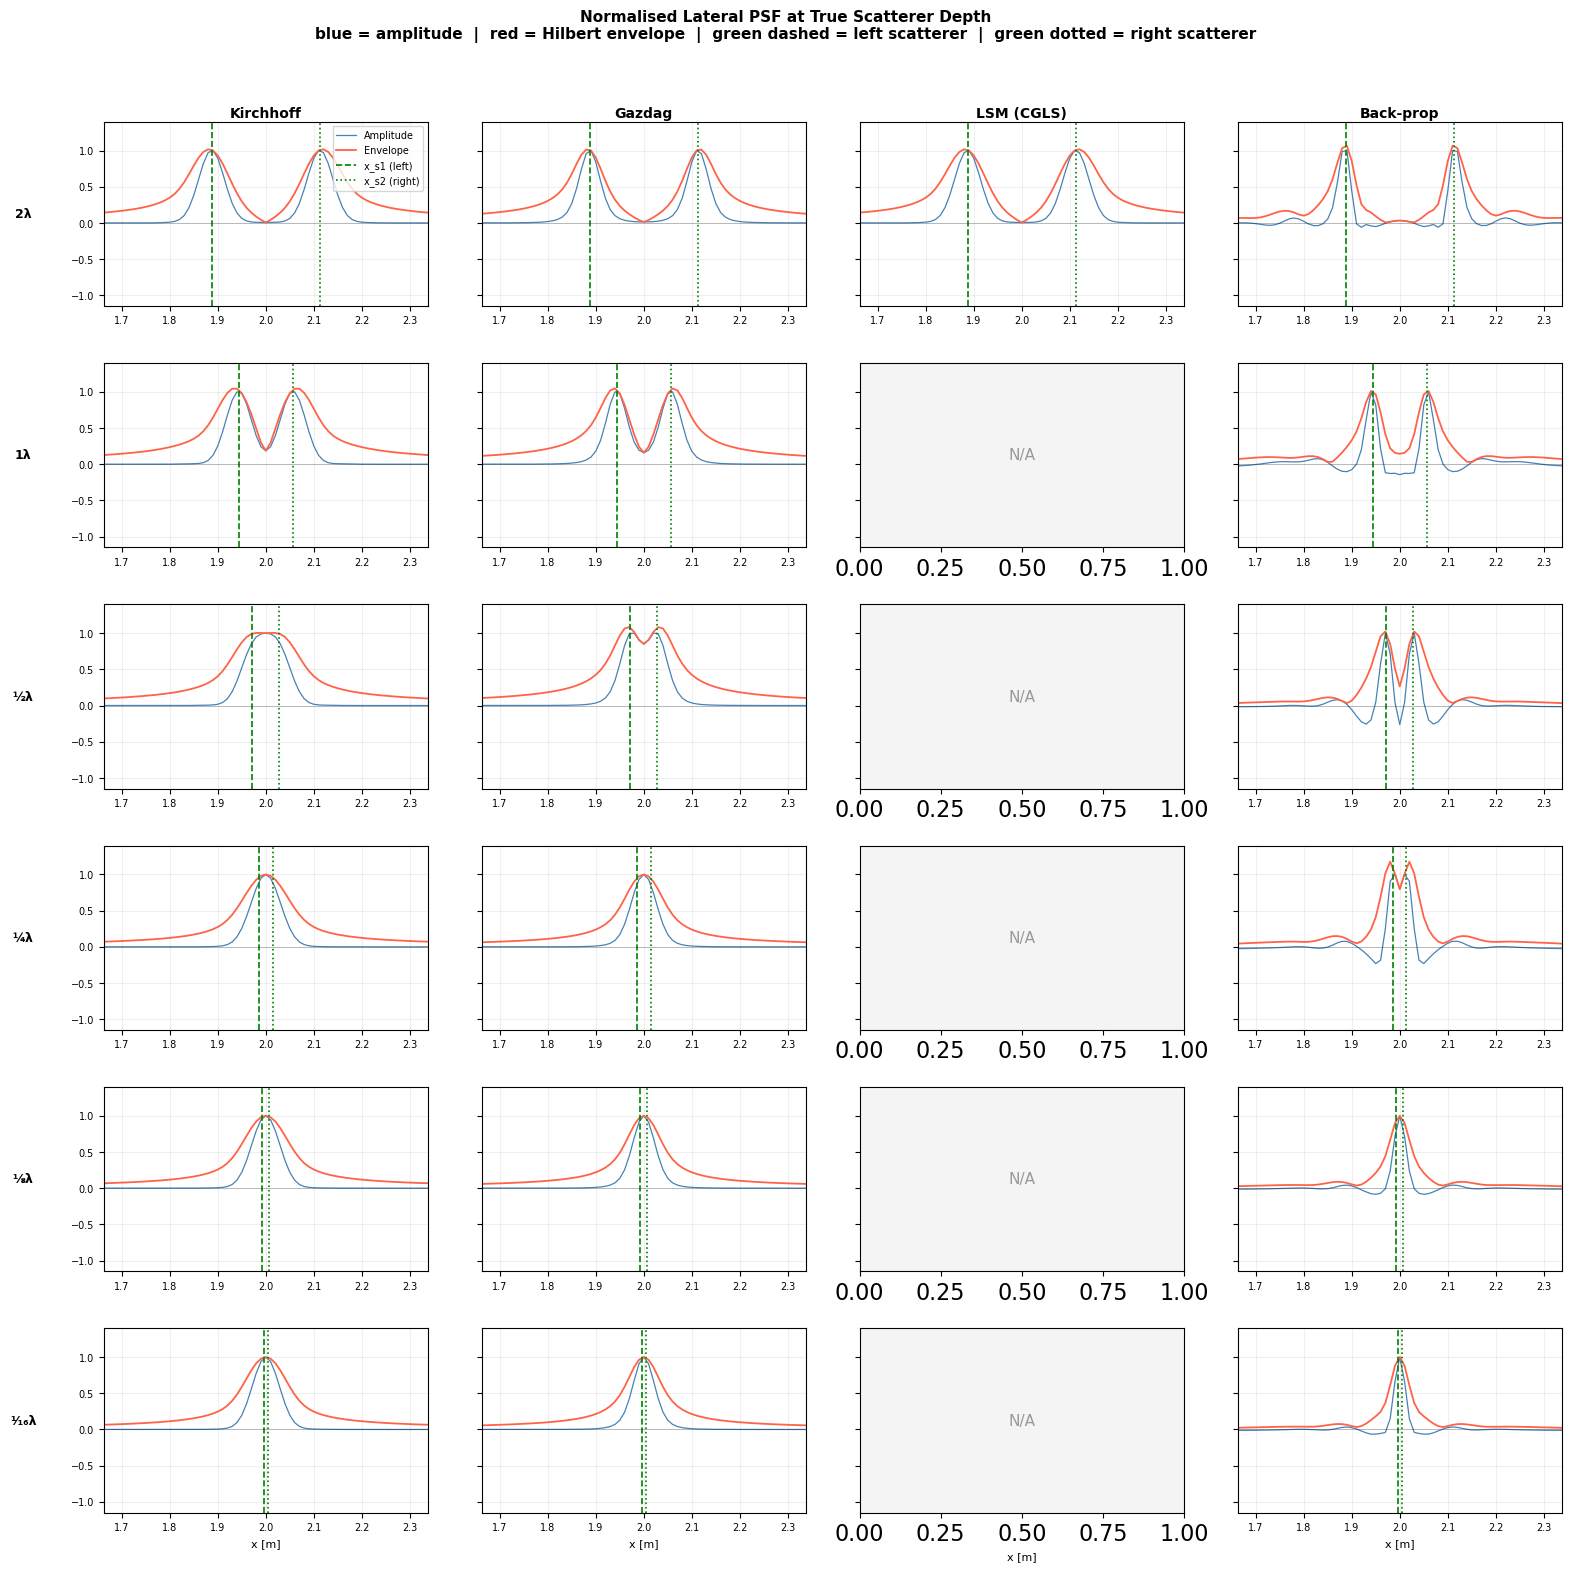

In [50]:
# ── Normalised lateral PSF at scatterer depth ─────────────────────────────────
# Rows = scenario (2λ to 1/16λ), Columns = method
# Extract a horizontal slice (constant depth = marker_z) across all x-traces.
# Both scatterers are symmetric around x_centre; window centres on x_centre.
# Blue  = signed amplitude (normalised to peak)
# Red   = Hilbert envelope
# Green dashed = left scatterer x-position
# Green dotted  = right scatterer x-position

x_win = 3.0 * wavelength   # half-window around x_centre [m]

fig_psf, axes_psf = plt.subplots(n_s, n_m,
                                  figsize=(4.0 * n_m, 2.6 * n_s),
                                  sharey=True)

for i, lbl in enumerate(labels):
    for j, method in enumerate(methods):
        ax  = axes_psf[i, j]
        img = imgs[i][j]

        if i == 0:
            ax.set_title(method, fontsize=10, fontweight='bold', pad=3)
        if j == 0:
            ax.set_ylabel(lbl, fontsize=9, fontweight='bold',
                          rotation=0, labelpad=34, va='center')
        if i == n_s - 1:
            ax.set_xlabel('x [m]', fontsize=8)

        if img is None:
            ax.text(0.5, 0.5, 'N/A', transform=ax.transAxes,
                    ha='center', va='center', fontsize=11, color='#999')
            ax.set_facecolor('#f4f4f4')
            continue

        # Depth index closest to true scatterer depth for this method
        marker_z = bp_z_top if j == 3 else z_top
        iz = int(np.argmin(np.abs(z_img - marker_z)))

        # Lateral profile at that depth, normalised to absolute peak
        profile  = img[iz, :].copy()
        peak     = np.max(np.abs(profile))
        if peak > 0:
            profile /= peak
        envelope = np.abs(scipy_hilbert(profile))

        ax.plot(x_traces, profile,  color='steelblue', lw=0.9, label='Amplitude')
        ax.plot(x_traces, envelope, color='tomato',    lw=1.3, label='Envelope')
        ax.axvline(x_scatterer_1[i], color='green', ls='--', lw=1.2,
                   label='x_s1 (left)')
        ax.axvline(x_scatterer_2[i], color='green', ls=':',  lw=1.2,
                   label='x_s2 (right)')
        ax.axhline(0, color='k', lw=0.4, alpha=0.4)
        ax.set_xlim(x_centre - x_win, x_centre + x_win)
        ax.set_ylim(-1.15, 1.4)
        ax.tick_params(labelsize=7)
        ax.grid(alpha=0.2)

axes_psf[0, 0].legend(fontsize=7, loc='upper right')

plt.suptitle(
    'Normalised Lateral PSF at True Scatterer Depth\n'
    'blue = amplitude  |  red = Hilbert envelope  '
    '|  green dashed = left scatterer  |  green dotted = right scatterer',
    fontsize=11, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig(STUDY_ROOT / 'psf_lateral_profiles.png', dpi=200, bbox_inches='tight')
plt.show()


# Save Migrated Results as np arrays dictionary

In [51]:
# ── Build structured numpy representation of all migrated results ─────────────
# imgs[scenario_idx][method_idx] is populated by the analysis cell above.
#   scenarios = labels   →  ["2λ", "1λ", "½λ", "¼λ", "⅛λ", "¹⁄₁₆λ"]
#   methods              →  ["Kirchhoff", "Gazdag", "LSM (CGLS)", "Back-prop"]
#   each image: shape (n_z, n_x) on the z_img × x_traces grid
#   LSM (CGLS) was run for the 2λ scenario only — None elsewhere.

_ref_shape = imgs[0][0].shape   # (n_z, n_x) reference from Kirchhoff 2λ

def _safe_stack(method_idx):
    """Stack imgs[:, method_idx] → (n_s, n_z, n_x); NaN where result is absent."""
    planes = []
    for i in range(n_s):
        arr = imgs[i][method_idx]
        planes.append(arr.astype(float) if arr is not None
                      else np.full(_ref_shape, np.nan))
    return np.stack(planes, axis=0)

mig_kirchhoff = _safe_stack(0)   # (6, n_z, n_x)
mig_gazdag    = _safe_stack(1)
mig_backprop  = _safe_stack(3)
lsm_cgls_2lam = imgs[0][2].astype(float) if imgs[0][2] is not None else None

# ── Save to disk ──────────────────────────────────────────────────────────────
save_path = STUDY_ROOT / "migrated_results.npz"

payload = dict(
    kirchhoff         = mig_kirchhoff,                                  # (6, n_z, n_x)
    gazdag            = mig_gazdag,
    backprop          = mig_backprop,
    scenarios         = np.array(labels,  dtype="U20"),                 # (6,)  string
    methods           = np.array(methods, dtype="U20"),                 # (4,)  string
    separation_lambda = np.array([2, 1, 0.5, 0.25, 0.125, 0.0625]),    # (6,)  float
    x_traces          = x_traces,                                       # (n_x,) m
    z_img             = z_img,                                          # (n_z,) m
    x_s1              = np.array(x_scatterer_1),                       # (6,) m  left-scatterer x
    x_s2              = np.array(x_scatterer_2),                       # (6,) m  right-scatterer x
    z_scatterer       = np.float64(z_scatterer),                       # scalar m  scatterer centre
    z_top             = np.float64(z_top),                             # scalar m  top of cylinder
)
if lsm_cgls_2lam is not None:
    payload["lsm_cgls_2lambda"] = lsm_cgls_2lam   # (n_z, n_x) — 2λ only

np.savez_compressed(save_path, **payload)

# ── In-memory convenience dict for this session ───────────────────────────────
# Usage: mig["Kirchhoff"]["½λ"]  or  mig_kirchhoff[2]  (index 2 = ½λ)
mig = {
    "Kirchhoff": {lbl: mig_kirchhoff[i] for i, lbl in enumerate(labels)},
    "Gazdag":    {lbl: mig_gazdag[i]    for i, lbl in enumerate(labels)},
    "Back-prop": {lbl: mig_backprop[i]  for i, lbl in enumerate(labels)},
}
if lsm_cgls_2lam is not None:
    mig["LSM (CGLS)"] = {labels[0]: lsm_cgls_2lam}

# ── Availability grid + summary ───────────────────────────────────────────────
print(f"Saved → {save_path}")
print(f"\nStacked arrays  (n_scenarios={n_s}, n_z={_ref_shape[0]}, n_x={_ref_shape[1]}):")
for name, arr in [("kirchhoff", mig_kirchhoff),
                  ("gazdag",    mig_gazdag),
                  ("backprop",  mig_backprop)]:
    absent = int(np.isnan(arr).all(axis=(1, 2)).sum())
    note   = f"  ({absent} scenario(s) absent → NaN)" if absent else ""
    print(f"  {name:<14}  {arr.shape}{note}")
if lsm_cgls_2lam is not None:
    print(f"  lsm_cgls      {lsm_cgls_2lam.shape}  (2λ only)")

print(f"\nAvailability  ✓ = computed   — = not run")
col_w = 14
print("  " + f"{'':>8}  " + "".join(f"{m:>{col_w}}" for m in methods))
for i, lbl in enumerate(labels):
    row = "  " + f"{lbl:>8}  "
    row += "".join(f"{'✓':>{col_w}}" if imgs[i][j] is not None else f"{'—':>{col_w}}"
                   for j in range(n_m))
    print(row)

print(f"\nAxes:")
print(f"  x_traces          {x_traces.shape}   {x_traces[0]:.3f} – {x_traces[-1]:.3f} m")
print(f"  z_img             {z_img.shape}   {z_img[0]:.3f} – {z_img[-1]:.3f} m")
print(f"  separation_lambda [2, 1, 0.5, 0.25, 0.125, 0.0625] (× wavelength)")

print(f"\nUsage examples:")
print(f"  d = np.load(str(STUDY_ROOT / 'migrated_results.npz'))")
print(f"  d['kirchhoff'][0]      # Kirchhoff  2λ  → shape (n_z, n_x)")
print(f"  d['gazdag'][3]         # Gazdag     ¼λ  → shape (n_z, n_x)")
print(f"  mig['Back-prop']['⅛λ'] # in-memory dict, same data")


Saved → C:\Users\Administrator\OneDrive\Thesis\TimeLapse_Notebooks\resolution_study\migrated_results.npz

Stacked arrays  (n_scenarios=6, n_z=160, n_x=380):
  kirchhoff       (6, 160, 380)
  gazdag          (6, 160, 380)
  backprop        (6, 160, 380)
  lsm_cgls      (160, 380)  (2λ only)

Availability  ✓ = computed   — = not run
                 Kirchhoff        Gazdag    LSM (CGLS)     Back-prop
        2λ               ✓             ✓             ✓             ✓
        1λ               ✓             ✓             —             ✓
        ½λ               ✓             ✓             —             ✓
        ¼λ               ✓             ✓             —             ✓
        ⅛λ               ✓             ✓             —             ✓
     ¹⁄₁₆λ               ✓             ✓             —             ✓

Axes:
  x_traces          (380,)   0.150 – 3.940 m
  z_img             (160,)   0.000 – 0.800 m
  separation_lambda [2, 1, 0.5, 0.25, 0.125, 0.0625] (× wavelength)

Usage examples:
  